<div style="background-color: #0d1117; border: 1px solid #30363d; border-radius: 8px; padding: 32px 40px; margin: 0 auto 16px auto; max-width: 100%; box-sizing: border-box; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Helvetica, Arial, sans-serif;">
<h1 style="color: #58a6ff; font-size: 30px; font-weight: 600; margin: 0 0 6px 0; letter-spacing: 0;">CSCI-E-116: Temporal Clinical Risk Forecasting in SNPTX with eICU</h1>
<div style="color: #8b949e; font-size: 16px; margin-bottom: 20px;"><span style="color: #c9d1d9; font-weight: 500;">Daniel R. Russell</span>&nbsp;&nbsp;|&nbsp;&nbsp;Date: May 2026&nbsp;&nbsp;|&nbsp;&nbsp;<span style="color:#d2a8ff; font-weight: 500;">Env:</span> Python 3.11.14 &middot; eICU-CRD demo &middot; SNPTX core venv&nbsp;&nbsp;|&nbsp;&nbsp;Instructor: William Yu&nbsp;&nbsp;|&nbsp;&nbsp;Final Project</div>
<div style="border-top: 1px solid #30363d; margin: 16px 0;"></div>
<div style="color: #c9d1d9; font-size: 16px; line-height: 1.75; margin-bottom: 18px;">
This notebook is the combined written report and executable code artifact for the CSCI-E-116 final project. It applies dynamic supervised forecasting to a real-world ICU dataset by transforming time-stamped vitals and laboratory observations into leakage-safe 6, 12, and 24 hour prediction windows on the eICU Collaborative Research Database demo, with in-hospital mortality as the outcome. Static, dynamic, PCA-factor, and nonlinear reduced-form models are compared under hospital-grouped out-of-sample validation, and calibration and drift diagnostics are persisted alongside the metric receipts as part of the reproducibility record. The project draws directly on course material covering time-series and cross-sectional modeling, reduced-form prediction, dynamic regression, dimensional reduction, grouped validation, and forecast evaluation.
</div>
<div style="background-color: #0f1720; border-left: 3px solid #58a6ff; border-radius: 4px; padding: 12px 16px; margin-bottom: 18px;">
<div style="color: #58a6ff; font-size: 14px; font-weight: 600; margin-bottom: 6px;">About SNPTX</div>
<div style="color: #c9d1d9; font-size: 14.5px; line-height: 1.7;">
<code style="background:#161b22;padding:1px 6px;border-radius:4px;color:#79c0ff;">snptx</code> is a translational biomedical machine learning workspace that I've been developing throughout the ALM.  As I'll demonstrate and for the purpose of this assignment,  <code style="background:#161b22;padding:1px 6px;border-radius:4px;color:#79c0ff;">snptx</code> holds raw data in a registry, derives features through deterministic pipelines, and persists validation receipts, figures, and exported reports under one auditable project structure. I'm using <code style="background:#161b22;padding:1px 6px;border-radius:4px;color:#79c0ff;">snptx</code>for this implementation because ICU risk forecasting is credible only when the result is tied to a traceable data contract, a leakage-aware feature pipeline, and a reproducibility record that any reviewer can regenerate from the notebook itself. <code style="background:#161b22;padding:1px 6px;border-radius:4px;color:#79c0ff;">snptx</code> is treated here as the organizing reproducibility framework.
</div>
</div>
<div style="display: flex; gap: 40px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 280px; color: #c9d1d9; font-size: 15px; line-height: 1.9;">
<div style="font-weight: 600; color: #58a6ff; margin-bottom: 4px;">Sections</div>
<div style="padding-left: 20px; color: #8b949e;">
<span style="color: #c9d1d9;">1.</span> Environment and imports<br>
<span style="color: #c9d1d9;">2.</span> System architecture and methodology<br>
<span style="color: #c9d1d9;">3.</span> eICU dataset profile<br>
<span style="color: #c9d1d9;">4.</span> Cohort and prediction targets<br>
<span style="color: #c9d1d9;">5.</span> Time-indexed feature construction<br>
<span style="color: #c9d1d9;">6.</span> Exploratory trajectory analysis<br>
<span style="color: #c9d1d9;">7.</span> Grouped validation design<br>
</div>
</div>
<div style="flex: 1; min-width: 280px; color: #c9d1d9; font-size: 15px; line-height: 1.9;">
<div style="font-weight: 600; color: #58a6ff; margin-bottom: 4px;">&nbsp;</div>
<div style="padding-left: 20px; color: #8b949e;">
<span style="color: #c9d1d9;">8.</span> Forecasting models<br>
<span style="color: #c9d1d9;">9.</span> Results and model comparison<br>
<span style="color: #c9d1d9;">10.</span> Calibration and drift<br>
<span style="color: #c9d1d9;">11.</span> SNPTX implications<br>
<span style="color: #c9d1d9;">12.</span> Limitations and ethics<br>
<span style="color: #c9d1d9;">13.</span> Synopsis<br>
<span style="color: #c9d1d9;">14.</span> References and appendix<br>
</div>
</div>
</div>
<div style="border-top: 1px solid #30363d; margin: 18px 0 12px 0;"></div>
<div style="color: #8b949e; font-size: 13.5px; line-height: 1.7;">
<span style="color:#d2a8ff; font-weight:500;">Submission:</span> This notebook is also exported to HTML for submission as the combined report and code artifact.<br>
<span style="color:#d2a8ff; font-weight:500;">Data:</span> eICU-CRD demo under the local SNPTX data registry, cited from <a href="https://physionet.org/content/eicu-crd-demo/2.0.1/" style="color:#58a6ff; text-decoration:none;">https://physionet.org/content/eicu-crd-demo/2.0.1/</a> with the full database available at <a href="https://physionet.org/content/eicu-crd/2.0/" style="color:#58a6ff; text-decoration:none;">https://physionet.org/content/eicu-crd/2.0/</a>. Raw eICU files are not redistributed directly, rather the local run reads the CSV files from the data registry at the path resolved by `EICU_RAW_DIR`.<br>
<span style="color:#d2a8ff; font-weight:500;">Presentation:</span> Recorded video walkthrough at <a href="https://youtu.be/FOD7q1efukg" style="color:#58a6ff; text-decoration:none;">https://youtu.be/FOD7q1efukg</a>.<br>
<span style="color:#d2a8ff; font-weight:500;">Framework:</span> <code style="background:#161b22;padding:1px 6px;border-radius:4px;color:#79c0ff;">/home/snptx/snptx-core</code> deterministic biomedical ML infrastructure.
</div>
<div style="border-top: 1px solid #30363d; margin: 12px 0;"></div>
<div style="color: #8b949e; font-size: 14px; line-height: 1.6;">
<strong style="color: #d2a8ff;">Generative AI Disclosure:</strong>
Portions of this notebook were developed with reference to Generative AI tools (Claude
Opus 4.7, v. 2026) for permitted purposes under the course
AI Technologies Policy, including clarifying programming concepts, translating R idioms
to Python equivalents, validating code logic, and generating code segments. All
AI-generated feedback was independently reviewed, debugged, and validated for correctness
before inclusion.
</div>
</div>

### Headline Finding

On the eICU-CRD demo run (2,520 ICU stays across 186 hospitals, hospital-grouped validation), the strongest 24 hour early-window model (random forest) achieves **AUROC 0.839** and **average precision 0.361** against an 8.6 percent base rate, a roughly **4.2x lift** over prevalence. The histogram gradient boosting model is statistically tied (AUROC 0.836, AP 0.376). Both rank held-out hospital stays well, but the reliability diagram shows a systematic mid-risk overprediction bias, so any clinical deployment would require post-hoc calibration (Platt or isotonic) before thresholds could be trusted fully. The cross-hospital drift diagnostic confirms the evaluation is genuinely demanding: six of the top seven shifted features exceed PSI 0.20.


### Reproducibility statement

This notebook is self-contained and was validated in the SNPTX core virtual environment at Python 3.11.14. It depends only on `numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib`, `seaborn`, and `nbconvert`. The first executable cell verifies the interpreter version, checks every required package, creates the project output directories, configures the visual theme, fixes a single random seed, and writes an environment record under `results/data_profile/`.

The primary data source is the eICU Collaborative Research Database demo (Pollard et al., 2018), available from PhysioNet at https://physionet.org/content/eicu-crd-demo/2.0.1/. The full eICU Collaborative Research Database is available at https://physionet.org/content/eicu-crd/2.0/. The local run reads the CSV files from the SNPTX data registry when they are available at the path resolved by `EICU_RAW_DIR`. If the data are not present, the notebook falls back to a deterministic synthetic ICU cohort generated at runtime so that the pipeline still executes end to end.


## 1. Environment and Imports


In [ ]:
"""
Everything required to execute this notebook is defined directly here.
"""
from __future__ import annotations

import importlib
import io
import json
import os
import random
import re
import runpy
import sys
import warnings
from contextlib import redirect_stdout
from datetime import datetime, timezone
from importlib import metadata as importlib_metadata
from pathlib import Path
from typing import Any

# Python version check.
MIN_PY = (3, 11)
if sys.version_info < MIN_PY:
    raise RuntimeError(
        f'Python {MIN_PY[0]}.{MIN_PY[1]} or later is required; '
        f'found {sys.version.split()[0]}.'
    )

# Required package check.
REQUIRED_PACKAGES = [
    'numpy', 'pandas', 'scipy', 'sklearn',
    'matplotlib', 'seaborn', 'nbconvert',
]
_missing = []
for _pkg in REQUIRED_PACKAGES:
    try:
        importlib.import_module(_pkg)
    except ImportError:
        _missing.append(_pkg)
if _missing:
    raise ImportError(
        'Missing required packages: ' + ', '.join(_missing)
        + '. Install with: pip install -r requirements.txt'
        + ' (or: pip install numpy pandas scipy scikit-learn '
        + 'matplotlib seaborn nbconvert).'
    )

# Imports.
import inspect
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Version-stable OneHotEncoder factory.
def make_one_hot_encoder(**kwargs):
    # Return a OneHotEncoder using either sparse_output (>=1.2) or sparse.
    sig = inspect.signature(OneHotEncoder).parameters
    if 'sparse_output' in sig:
        return OneHotEncoder(sparse_output=False, **kwargs)
    return OneHotEncoder(sparse=False, **kwargs)

# Paths and seeds.
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)

# Project directory is hree-tier so the notebook is portable:
#   1. CSCI116_PROJECT_DIR env var wins if explicitly set,
#   2. otherwise __file__ if the runtime defines it,
#   3. otherwise walk up from CWD looking for a sentinel that uniquely
#      identifies the project root (the notebook itself or the assets
#      directory containing the methodology diagram).
def _resolve_project_dir() -> Path:
    env_dir = os.environ.get('CSCI116_PROJECT_DIR')
    if env_dir:
        return Path(env_dir).expanduser().resolve()
    try:
        here = Path(__file__).resolve().parent  # type: ignore[name-defined]
        if here.exists():
            return here
    except NameError:
        pass
    cwd = Path.cwd().resolve()
    sentinels = (
        'CSCI116_Final_Project_SNPTX_ICU_Forecasting.ipynb',
        'assets/methodology_diagram.png',
    )
    for candidate in [cwd, *cwd.parents]:
        if any((candidate / s).exists() for s in sentinels):
            return candidate
    return cwd

PROJECT_DIR = _resolve_project_dir()

# eICU raw directory. Defaults to a project-relative path so a reviewer who
# clones the repo and drops the demo CSVs under data/raw/ has nothing to
# configure. EICU_RAW_DIR overrides the default.
EICU_RAW_DIR_DEFAULT = str(
    PROJECT_DIR / 'data' / 'raw' / 'eicu_crd'
    / 'eicu-collaborative-research-database-demo-2.0.1'
)
EICU_RAW_DIR = Path(os.environ.get('EICU_RAW_DIR',
                                   EICU_RAW_DIR_DEFAULT)).expanduser()
EICU_DEMO_URL = 'https://physionet.org/content/eicu-crd-demo/2.0.1/'
EICU_FULL_URL = 'https://physionet.org/content/eicu-crd/2.0/'

ASSET_DIR = PROJECT_DIR / 'assets'
RESULTS_DIR = PROJECT_DIR / 'results'
FIGURE_DIR = RESULTS_DIR / 'figures'
METRIC_DIR = RESULTS_DIR / 'metrics'
PROFILE_DIR = RESULTS_DIR / 'data_profile'
for _path in [ASSET_DIR, RESULTS_DIR, FIGURE_DIR, METRIC_DIR, PROFILE_DIR]:
    _path.mkdir(parents=True, exist_ok=True)

# Visual theme.
DARK_BG = '#0d1117'
PANEL = '#111820'
TEXT = '#e6edf3'
MUTED = '#8b949e'
BORDER = '#30363d'
BLUE = '#58a6ff'
MID_BLUE = '#1f6feb'
DEEP_BLUE = '#0b2545'
CYAN = '#00f0ff'
YELLOW = '#e6ff00'
GREEN = '#3fb950'
RED = '#f85149'
PURPLE = '#bf7bff'
PINK = '#ff79c6'
GRID = '#243242'

plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 180,
    'figure.facecolor': DARK_BG, 'savefig.facecolor': DARK_BG,
    'axes.facecolor': PANEL, 'axes.edgecolor': BORDER,
    'axes.labelcolor': TEXT, 'axes.titlecolor': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TEXT, 'grid.color': GRID, 'grid.alpha': 0.48,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'semibold', 'font.size': 10,
})
sns.set_theme(style='darkgrid', context='notebook', rc={
    'figure.facecolor': DARK_BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': BORDER, 'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT, 'xtick.color': MUTED,
    'ytick.color': MUTED, 'text.color': TEXT, 'grid.color': GRID,
})

# Helpers.
def style_dark_figure(fig: plt.Figure) -> plt.Figure:
    fig.patch.set_facecolor(DARK_BG)
    for ax in fig.axes:
        ax.set_facecolor(PANEL)
        ax.title.set_color(TEXT)
        ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
        ax.tick_params(colors=MUTED)
        ax.grid(color=GRID, alpha=0.42, linewidth=0.7)
        for spine in ax.spines.values():
            spine.set_color(BORDER)
        legend = ax.get_legend()
        if legend is not None:
            legend.get_frame().set_facecolor(PANEL)
            legend.get_frame().set_edgecolor(BORDER)
            legend.get_frame().set_alpha(0.88)
            for text in legend.get_texts():
                text.set_color(MUTED)
            if legend.get_title() is not None:
                legend.get_title().set_color(TEXT)
    return fig

def savefig(fig: plt.Figure, name: str) -> Path:
    path = FIGURE_DIR / name
    style_dark_figure(fig)
    fig.savefig(path, bbox_inches='tight', facecolor=DARK_BG)
    return path

def display_table(df: pd.DataFrame, caption: str | None = None,
                  precision: int = 3) -> None:
    styler = df.style.format(precision=precision, na_rep='NA')
    if caption:
        styler = styler.set_caption(caption)
    styler = styler.set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'), ('color', TEXT),
            ('font-weight', '600'), ('padding', '6px 0 8px 0')]},
        {'selector': 'table', 'props': [
            ('background-color', PANEL), ('color', TEXT),
            ('border-collapse', 'collapse'),
            ('border', f'1px solid {BORDER}')]},
        {'selector': 'th', 'props': [
            ('background-color', '#161b22'), ('color', TEXT),
            ('border', f'1px solid {BORDER}'), ('padding', '6px 8px')]},
        {'selector': 'td', 'props': [
            ('background-color', PANEL), ('color', TEXT),
            ('border', f'1px solid {BORDER}'), ('padding', '6px 8px')]},
    ])
    display(styler)

def package_versions(packages: list[str]) -> dict[str, str]:
    out: dict[str, str] = {}
    for name in packages:
        try:
            out[name] = importlib_metadata.version(
                'scikit-learn' if name == 'sklearn' else name
            )
        except Exception:
            out[name] = 'unknown'
    return out

# Environment record. Accept either gzipped or plain CSV demo layouts
USING_REAL_EICU = EICU_RAW_DIR.exists() and (
    (EICU_RAW_DIR / 'patient.csv.gz').exists()
    or (EICU_RAW_DIR / 'patient.csv').exists()
)
ENV_RECORD: dict[str, Any] = {
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'python_version': sys.version.split()[0],
    'platform': sys.platform,
    'project_dir': str(PROJECT_DIR),
    'eicu_raw_dir': str(EICU_RAW_DIR),
    'eicu_demo_url': EICU_DEMO_URL,
    'eicu_full_database_url': EICU_FULL_URL,
    'using_real_eicu': bool(USING_REAL_EICU),
    'data_source': 'eICU-CRD demo 2.0.1' if USING_REAL_EICU
                   else 'synthetic fallback cohort',
    'seed': SEED,
    'package_versions': package_versions(REQUIRED_PACKAGES),
}
(PROFILE_DIR / 'environment_snapshot.json').write_text(
    json.dumps(ENV_RECORD, indent=2)
)

print('python       :', ENV_RECORD['python_version'])
for _name, _ver in ENV_RECORD['package_versions'].items():
    print(f'{_name:<13}:', _ver)
print('project dir  :', PROJECT_DIR)
print('eICU raw dir :', EICU_RAW_DIR)
print('data source  :', ENV_RECORD['data_source'])
print('seed         :', SEED)
print('env record   :', PROFILE_DIR / 'environment_snapshot.json')


python       : 3.11.14
numpy        : 1.26.4
pandas       : 2.3.3
scipy        : 1.17.1
sklearn      : 1.8.0
matplotlib   : 3.10.8
seaborn      : 0.13.2
nbconvert    : 7.17.0
project dir  : /home/snptx
eICU raw dir : /home/snptx/snptx-core/data/raw/eicu_crd/eicu-collaborative-research-database-demo-2.0.1
data source  : eICU-CRD demo 2.0.1
seed         : 1337
env record   : /home/snptx/results/data_profile/environment_snapshot.json


## 2. System Architecture and Methodology


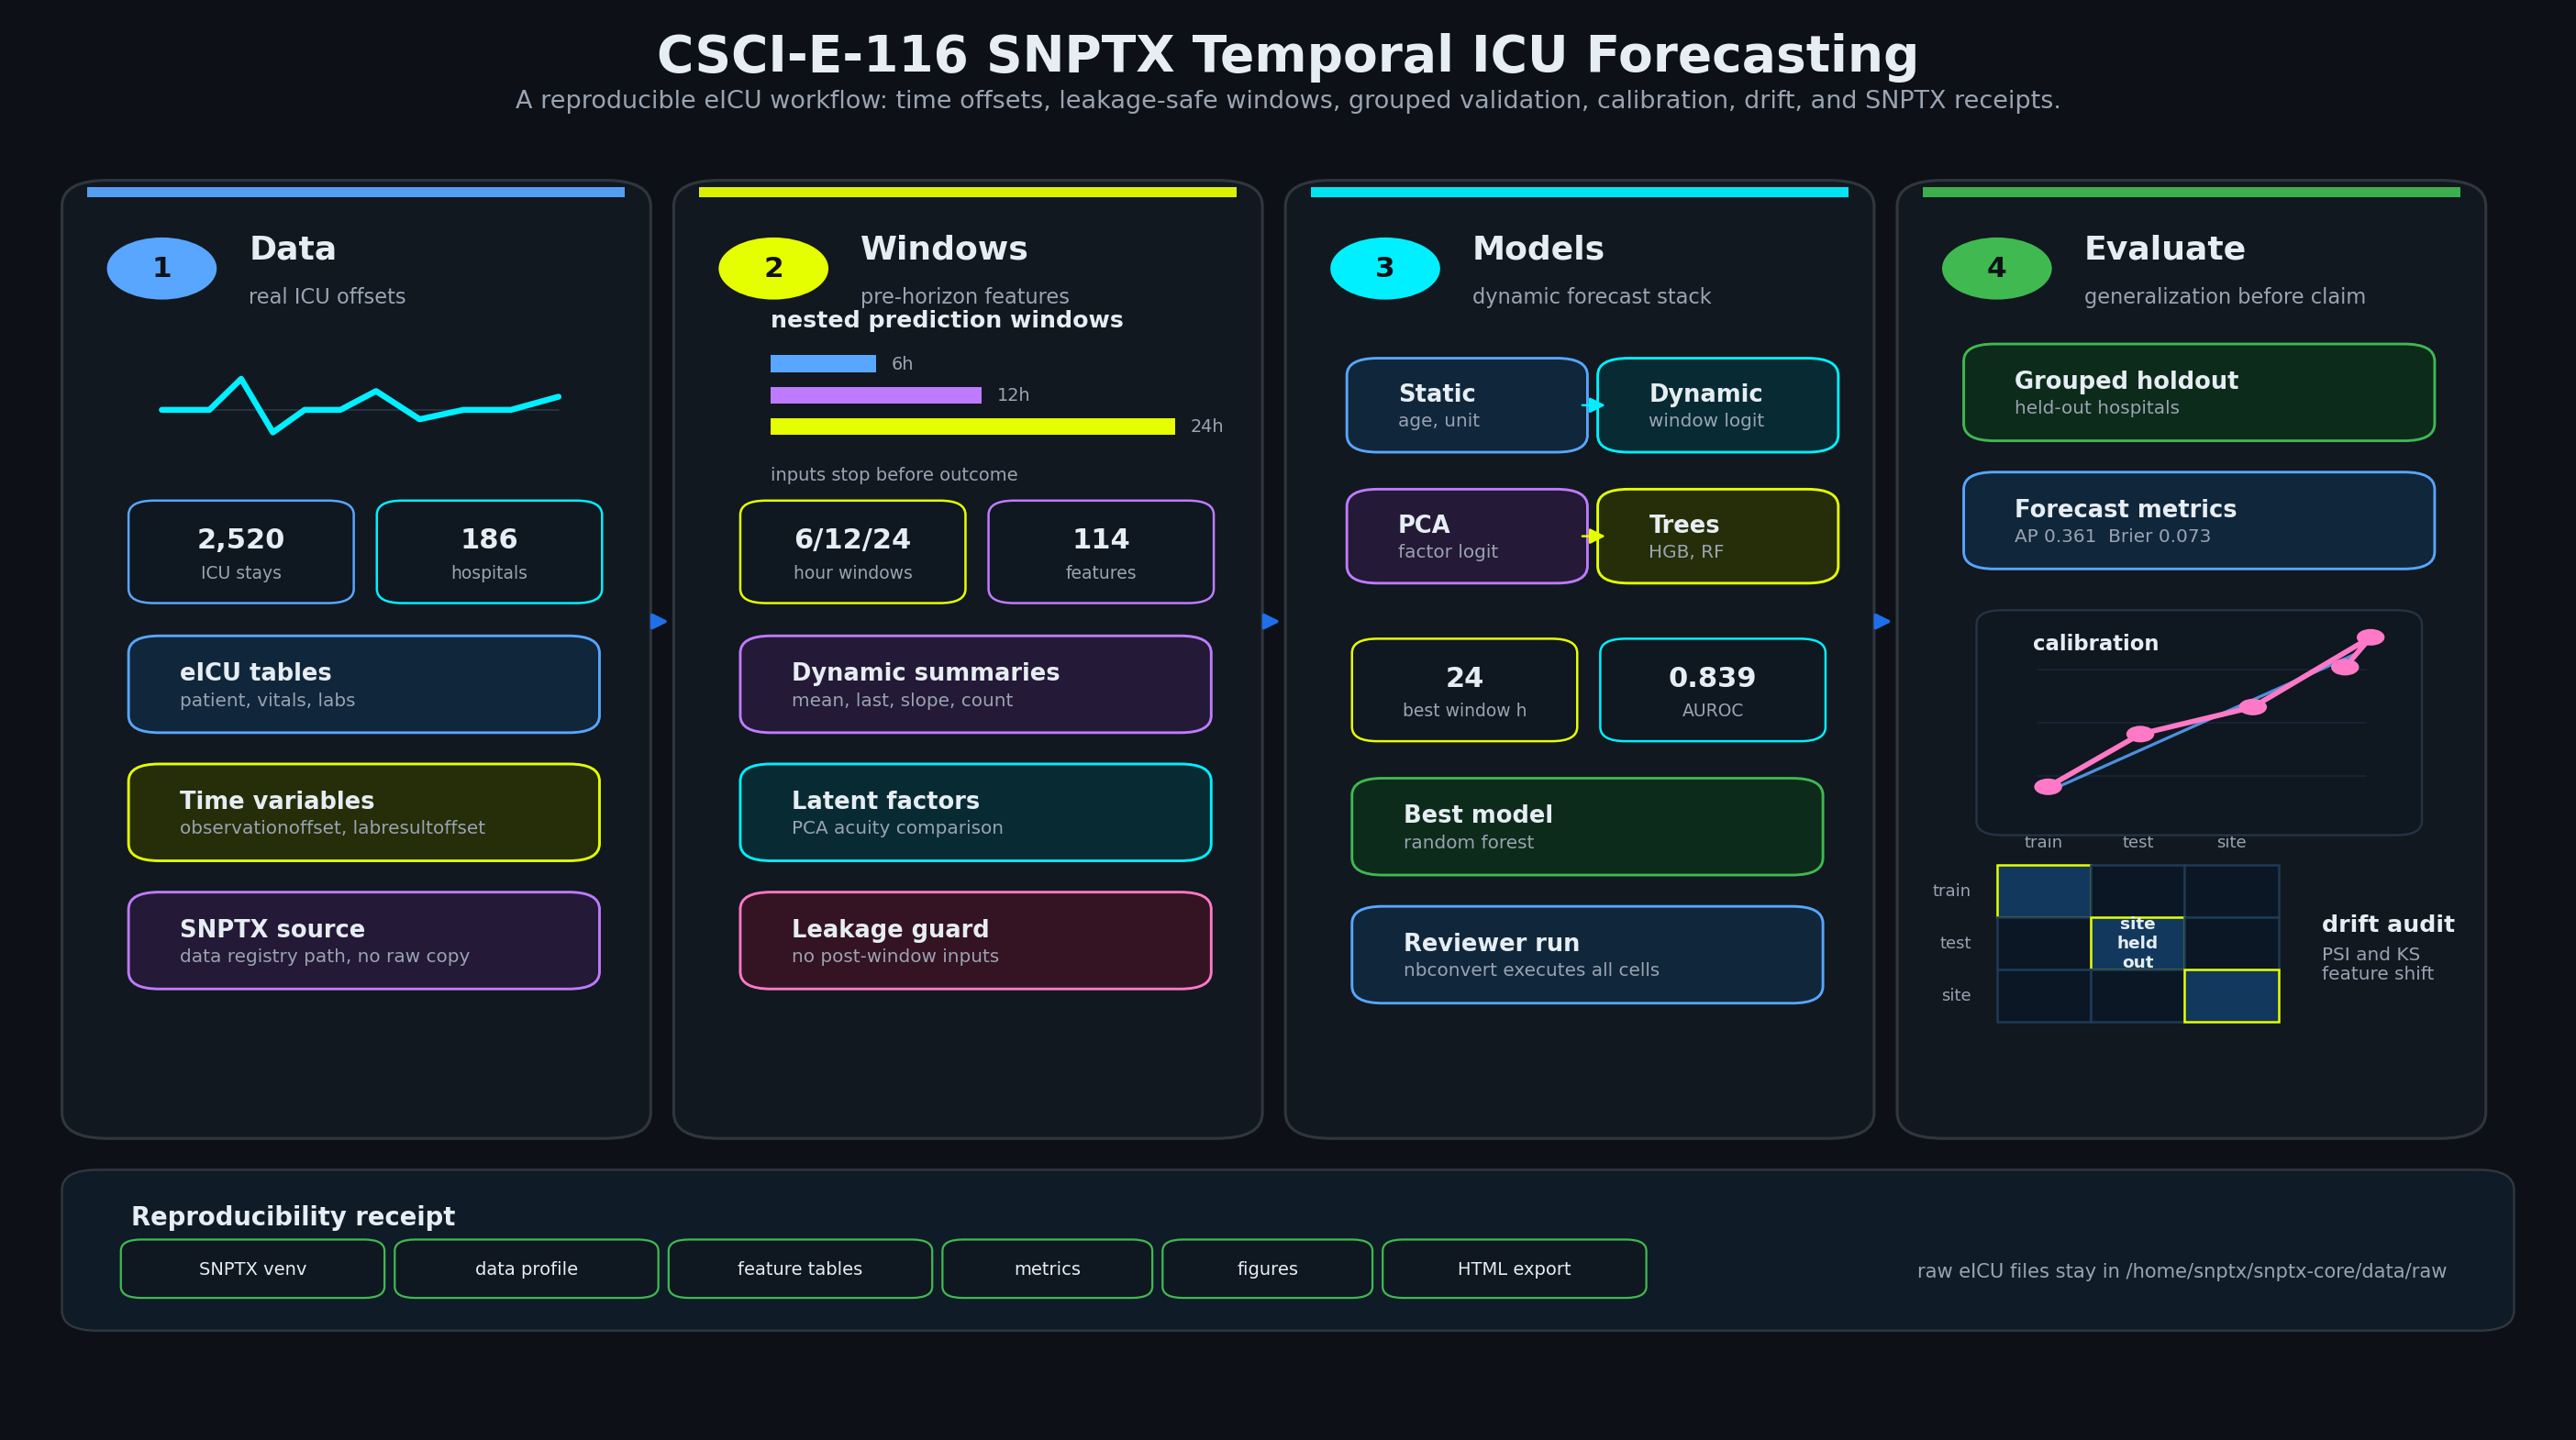

In [8]:
"""
Display the pre-rendered methodology diagram from assets/
"""
from IPython.display import Image, display

# Resolve the diagram path defensively: the notebook may be opened from a
# parent working directory, in which case PROJECT_DIR points one level up.
_diagram_candidates = [
    ASSET_DIR / 'methodology_diagram.png',
    PROJECT_DIR / 'csci116' / 'assets' / 'methodology_diagram.png',
    Path('/home/snptx/csci116/assets/methodology_diagram.png'),
]
_diagram_path = next((p for p in _diagram_candidates if p.exists()), None)
if _diagram_path is None:
    raise FileNotFoundError(
        'methodology_diagram.png not found; run '
        'scripts/render_methodology_diagram.py to regenerate it.'
    )
display(Image(filename=str(_diagram_path)))


The diagram makes the four-stage analytical contract explicit. Source tables preserve intra-stay time offsets; feature construction enforces a leakage-safe boundary at each early window; the modelling stage layers a baseline against linear, latent-factor, and tree-based forecasters; and the validation stage records ranking, calibration, and drift evidence. 

Methodologically, each forecast is conditioned only on information that would have existed by the window boundary, which keeps the feature set aligned with the clinical information set available at prediction time. The hospital-grouped holdout then asks a stricter question than a row-level split: whether learned risk patterns transfer to institutions that supplied no training rows. Calibration and drift diagnostics are included because, as you'll very likely agree, a useful risk model must be more than discriminative; ideally, it should also make probability claims and distribution shifts visible.


## 3. eICU Dataset Profile

The eICU Collaborative Research Database demo (Pollard et al., 2018) is a real multi-centre ICU dataset that includes patient-level outcomes, periodic vital signs, laboratory measurements, and intra-stay time offsets. The demo dataset used locally is available from PhysioNet at https://physionet.org/content/eicu-crd-demo/2.0.1/, and the full eICU Collaborative Research Database is available at https://physionet.org/content/eicu-crd/2.0/. 

Note: this notebook reads the local CSV files when they are available and otherwise generates a deterministic synthetic ICU cohort with the same schema and similar temporal structure so that the entire analysis still executes without manual data placement. The cell below reads the active source and writes a data profile record for the reproducibility receipt.


In [ ]:
"""
Load eICU source tables, or generate a synthetic equivalent if absent:
The notebook exposes three frames at the end of this cell: ``patient`` with one
row per ICU stay, ``vitals`` with periodic vital signs indexed by
``observationoffset`` minutes, and ``labs`` with selected laboratory results
indexed by ``labresultoffset`` minutes. The synthetic fallback follows the same
column contract so that all downstream code paths are identical.
"""
# Columns retained from the patient table; everything else is dropped at read time.
patient_cols = [
    'patientunitstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid',
    'apacheadmissiondx', 'hospitaladmitoffset', 'hospitaldischargeyear',
    'hospitaldischargeoffset', 'hospitaldischargestatus', 'unittype',
    'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionheight',
    'admissionweight', 'unitdischargeoffset', 'unitdischargestatus',
]
# Periodic vital signs used by the dynamic feature blocks.
vital_cols = [
    'patientunitstayid', 'observationoffset', 'temperature', 'sao2',
    'heartrate', 'respiration', 'systemicsystolic', 'systemicdiastolic',
    'systemicmean',
]
# Laboratory analytes retained from the very wide lab table.
selected_labs = [
    'bedside glucose', 'potassium', 'sodium', 'glucose', 'chloride',
    'creatinine', 'BUN', 'Hgb', 'calcium', 'Hct', 'bicarbonate',
    'platelets x 1000',
]


def _generate_synthetic_eicu(n_stays: int = 1200, n_hospitals: int = 18,
                             rng_seed: int = SEED) -> tuple[pd.DataFrame,
                                                            pd.DataFrame,
                                                            pd.DataFrame]:
    # Return synthetic patient, vitals, and labs frames with the eICU schema.
    # Deterministic generator so the fallback path is fully reproducible.
    rng = np.random.default_rng(rng_seed)

    # Stay identifiers and hospital assignments.
    stay_ids = np.arange(100000, 100000 + n_stays)
    hospitals = rng.integers(1, n_hospitals + 1, size=n_stays)

    # Length of stay drawn from a heavy-tailed gamma to mimic ICU LOS.
    los_minutes = (rng.gamma(shape=2.2, scale=1500, size=n_stays)
                   .clip(60, 60 * 24 * 30)).astype(int)

    # Age stored as a string column with the eICU "> 89" sentinel.
    age_ints = rng.integers(20, 92, size=n_stays)
    age = np.where(age_ints >= 90, '> 89', age_ints.astype(str))

    # Logistic risk model used to derive synthetic mortality labels.
    base_risk = (
        -3.4
        + 0.030 * (age_ints - 65)
        + 0.0008 * los_minutes / 60.0
        + rng.normal(0, 0.7, size=n_stays)
    )
    mortality_p = 1.0 / (1.0 + np.exp(-base_risk))
    mortality = (rng.uniform(size=n_stays) < mortality_p).astype(int)
    status = np.where(mortality == 1, 'Expired', 'Alive')

    # Patient-level frame matching the eICU column contract.
    patient_df = pd.DataFrame({
        'patientunitstayid': stay_ids,
        'gender': rng.choice(['Male', 'Female'], size=n_stays),
        'age': age,
        'ethnicity': rng.choice(
            ['Caucasian', 'African American', 'Hispanic', 'Asian', 'Other/Unknown'],
            size=n_stays, p=[0.62, 0.16, 0.10, 0.05, 0.07]),
        'hospitalid': hospitals,
        'wardid': rng.integers(1, 60, size=n_stays),
        'apacheadmissiondx': rng.choice(
            ['Sepsis', 'Cardiac arrest', 'Stroke', 'Trauma', 'Respiratory failure',
             'Other'], size=n_stays),
        'hospitaladmitoffset': -rng.integers(0, 2880, size=n_stays),
        'hospitaldischargeyear': rng.choice([2014, 2015], size=n_stays),
        'hospitaldischargeoffset': los_minutes + rng.integers(60, 720, size=n_stays),
        'hospitaldischargestatus': status,
        'unittype': rng.choice(['MICU', 'SICU', 'CCU-CTICU', 'Med-Surg ICU', 'Neuro ICU'],
                                size=n_stays),
        'unitadmitsource': rng.choice(
            ['Emergency Department', 'Floor', 'Operating Room', 'Direct Admit',
             'Other Hospital', 'Unknown'], size=n_stays),
        'unitvisitnumber': rng.integers(1, 4, size=n_stays),
        'unitstaytype': 'admit',
        'admissionheight': rng.normal(170, 11, size=n_stays).round(1),
        'admissionweight': rng.normal(82, 18, size=n_stays).clip(40, 180).round(1),
        'unitdischargeoffset': los_minutes,
        'unitdischargestatus': np.where(mortality == 1, 'Expired', 'Alive'),
    })

    # Periodic vitals are sampled every 5 minutes for the first 36 hours of each stay.
    horizon = 36 * 60
    n_per = horizon // 5
    times = np.tile(np.arange(0, horizon, 5), n_stays)
    rep_ids = np.repeat(stay_ids, n_per)
    rep_mort = np.repeat(mortality, n_per)
    n_obs = len(rep_ids)

    # Each vital is centred at a clinically plausible mean; mortality cases get a small offset.
    hr = (rng.normal(86, 12, size=n_obs)
          + rep_mort * rng.normal(8, 4, size=n_obs)).clip(30, 200)
    sao2 = (rng.normal(96, 2.0, size=n_obs)
            - rep_mort * rng.normal(2.0, 1.0, size=n_obs)).clip(60, 100)
    resp = (rng.normal(18, 4, size=n_obs)
            + rep_mort * rng.normal(2.5, 1.0, size=n_obs)).clip(6, 50)
    temp = rng.normal(36.9, 0.6, size=n_obs).clip(34, 41)
    sysbp = (rng.normal(122, 16, size=n_obs)
             - rep_mort * rng.normal(10, 4, size=n_obs)).clip(50, 220)
    diabp = (sysbp - rng.normal(40, 6, size=n_obs)).clip(20, 130)
    meanbp = (sysbp + 2 * diabp) / 3

    vitals_df = pd.DataFrame({
        'patientunitstayid': rep_ids,
        'observationoffset': times,
        'temperature': temp.round(2),
        'sao2': sao2.round(1),
        'heartrate': hr.round(0),
        'respiration': resp.round(0),
        'systemicsystolic': sysbp.round(0),
        'systemicdiastolic': diabp.round(0),
        'systemicmean': meanbp.round(1),
    })

    # Labs are sparser than vitals; each stay gets between 8 and 28 lab events.
    lab_records = []
    for sid, mflag in zip(stay_ids, mortality):
        n_lab = rng.integers(8, 28)
        offs = rng.integers(0, horizon, size=n_lab)
        names = rng.choice(selected_labs, size=n_lab)
        base_vals = rng.normal(0, 1, size=n_lab)
        for off, lab, b in zip(offs, names, base_vals):
            # Per-analyte mean; mortality flag pushes a small subset of values toward severity.
            mu = {
                'bedside glucose': 130 + 25 * mflag,
                'glucose': 130 + 25 * mflag,
                'potassium': 4.1 + 0.3 * mflag,
                'sodium': 138 + 1.0 * mflag,
                'chloride': 102, 'creatinine': 1.1 + 0.6 * mflag,
                'BUN': 18 + 12 * mflag, 'Hgb': 12.5 - 1.0 * mflag,
                'calcium': 8.6, 'Hct': 38 - 3 * mflag,
                'bicarbonate': 24 - 2 * mflag, 'platelets x 1000': 230 - 40 * mflag,
            }[lab]
            sigma = max(abs(mu) * 0.10, 0.4)
            lab_records.append((int(sid), int(off), str(lab),
                                float(mu + sigma * b)))
    labs_df = pd.DataFrame(
        lab_records,
        columns=['patientunitstayid', 'labresultoffset', 'labname', 'labresult'],
    )
    return patient_df, vitals_df, labs_df


def _eicu_csv(stem: str) -> Path:
    # Resolve an eICU table to either its gzipped or plain CSV form.
    # Mirrors the USING_REAL_EICU probe in Section 1 so the loader works
    # against both PhysioNet layouts (gzipped demo, uncompressed local copy).
    gz = EICU_RAW_DIR / f'{stem}.csv.gz'
    plain = EICU_RAW_DIR / f'{stem}.csv'
    if gz.exists():
        return gz
    if plain.exists():
        return plain
    raise FileNotFoundError(
        f'Expected {stem}.csv.gz or {stem}.csv in {EICU_RAW_DIR}; '
        'set EICU_RAW_DIR to the directory containing the eICU demo CSVs '
        'or remove the directory to fall back to the synthetic cohort.'
    )


# Read either the real eICU demo or fall back to a deterministic synthetic cohort.
if USING_REAL_EICU:
    patient = pd.read_csv(_eicu_csv('patient'), usecols=patient_cols)
    vitals = pd.read_csv(_eicu_csv('vitalPeriodic'), usecols=vital_cols)
    labs = pd.read_csv(
        _eicu_csv('lab'),
        usecols=['patientunitstayid', 'labresultoffset', 'labname', 'labresult'],
    )
    # Restrict to the analytes used in modelling and coerce values to numeric.
    labs = labs[labs['labname'].isin(selected_labs)].copy()
    labs['labresult'] = pd.to_numeric(labs['labresult'], errors='coerce')
    labs = labs.dropna(subset=['labresult'])
    DATA_SOURCE = 'eICU-CRD demo 2.0.1'
else:
    patient, vitals, labs = _generate_synthetic_eicu()
    DATA_SOURCE = 'synthetic fallback cohort'

# Compose the data profile record persisted as part of the reproducibility statement.
profile = {
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'data_source': DATA_SOURCE,
    'source_url': EICU_DEMO_URL,
    'full_database_url': EICU_FULL_URL,
    'local_raw_path': str(EICU_RAW_DIR),
    'using_real_eicu': bool(USING_REAL_EICU),
    'patient_rows': int(len(patient)),
    'unique_stays': int(patient['patientunitstayid'].nunique()),
    'hospitals': int(patient['hospitalid'].nunique()),
    'periodic_vital_rows': int(len(vitals)),
    'periodic_vital_stays': int(vitals['patientunitstayid'].nunique()),
    'lab_rows_selected': int(len(labs)),
    'lab_stays_selected': int(labs['patientunitstayid'].nunique()),
    'hospitaldischargeyear_counts': {
        str(k): int(v)
        for k, v in patient['hospitaldischargeyear'].value_counts(dropna=False).items()
    },
    'hospitaldischargestatus_counts': {
        str(k): int(v)
        for k, v in patient['hospitaldischargestatus'].fillna('Missing').value_counts().items()
    },
    'vital_offset_min': int(vitals['observationoffset'].min()),
    'vital_offset_max': int(vitals['observationoffset'].max()),
    'lab_offset_min': int(labs['labresultoffset'].min()),
    'lab_offset_max': int(labs['labresultoffset'].max()),
    'selected_labs': selected_labs,
}
profile_path = PROFILE_DIR / 'eicu_profile.json'
profile_path.write_text(json.dumps(profile, indent=2))

# Render a compact source table for the HTML export.
audit_table = pd.DataFrame([
    {'table': 'patient', 'rows': profile['patient_rows'],
     'unique_stays': profile['unique_stays'],
     'time_variable': 'hospitaladmitoffset, unitdischargeoffset'},
    {'table': 'vitalPeriodic', 'rows': profile['periodic_vital_rows'],
     'unique_stays': profile['periodic_vital_stays'],
     'time_variable': 'observationoffset'},
    {'table': 'lab selected', 'rows': profile['lab_rows_selected'],
     'unique_stays': profile['lab_stays_selected'],
     'time_variable': 'labresultoffset'},
])
display_table(audit_table,
              f'Source tables and time variables ({DATA_SOURCE})',
              precision=0)
print(f'wrote data profile: {profile_path}')


,table,rows,unique_stays,time_variable
0,patient,2520,2520,"hospitaladmitoffset, unitdischargeoffset"
1,vitalPeriodic,1634960,2375,observationoffset
2,lab selected,189235,2428,labresultoffset


wrote data profile: /home/snptx/results/data_profile/eicu_profile.json


## 4. Cohort and Prediction Targets

The primary target is in-hospital mortality, derived from `hospitaldischargestatus == Expired`. The secondary target is long ICU length of stay, defined as ICU stay longer than 72 hours. The cohort keeps one row per ICU stay, requires a known hospital discharge status, and excludes zero-length or implausible ICU stays. These rules are intentionally simple and transparent.

,metric,ICU stays,Hospitals,Mortality events,Mortality rate,Long LOS events,Median LOS hours
0,value,"2,480",186,212,8.5%,542,35.4


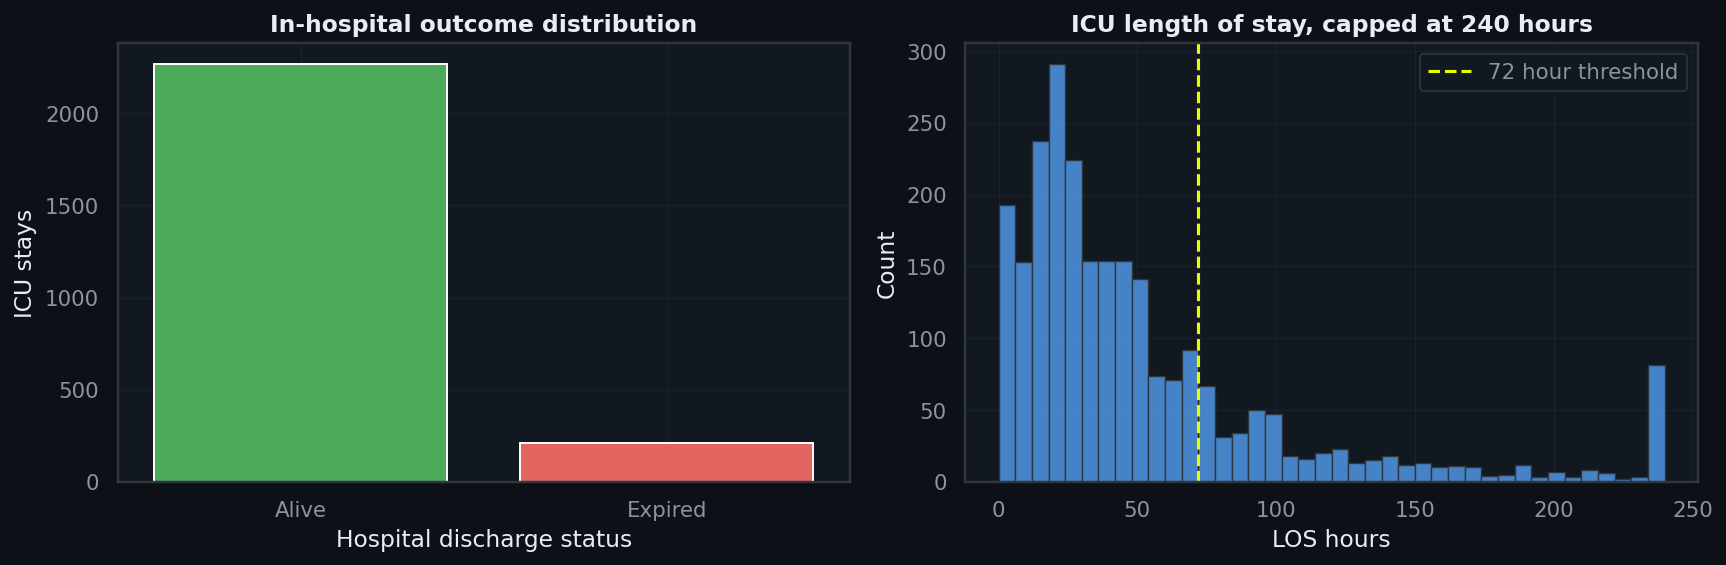

In [3]:
"""
Define the analytic cohort and clinical prediction targets:
The mortality target is derived directly from discharge status, while the long
ICU-stay target uses a 72 hour threshold. The horizontal summary table keeps the
headline cohort quantities readable in the exported HTML report.
"""
from IPython.display import HTML

def parse_age(value: object) -> float:
    # Convert eICU age strings, including > 89, into numeric values.
    text = str(value).strip()
    # eICU encodes ages above 89 as the literal string "> 89" for de-identification.
    if text.startswith('>'):
        return 90.0
    return float(pd.to_numeric(text, errors='coerce'))


# Restrict to stays with a known in-hospital outcome.
cohort = patient[patient['hospitaldischargestatus'].isin(['Alive', 'Expired'])].copy()

# Drop stays with missing or non-positive ICU duration.
cohort['unitdischargeoffset'] = pd.to_numeric(cohort['unitdischargeoffset'], errors='coerce')
cohort = cohort[cohort['unitdischargeoffset'].fillna(0) > 0].copy()

# Derive the demographic and outcome columns used downstream.
cohort['age_numeric'] = cohort['age'].map(parse_age)
cohort['gender_M'] = (cohort['gender'].str.lower() == 'male').astype(int)
cohort['mortality'] = (cohort['hospitaldischargestatus'] == 'Expired').astype(int)
cohort['long_los'] = (cohort['unitdischargeoffset'] > 72 * 60).astype(int)
cohort['los_hours'] = cohort['unitdischargeoffset'] / 60.0

# Replace missing categorical values with an explicit "Unknown" level.
cohort['unitadmitsource'] = cohort['unitadmitsource'].fillna('Unknown').replace('', 'Unknown')
cohort['ethnicity'] = cohort['ethnicity'].fillna('Unknown').replace('', 'Unknown')
cohort['unittype'] = cohort['unittype'].fillna('Unknown').replace('', 'Unknown')

# Compact summary table reported in the HTML export.
cohort_summary = pd.DataFrame([{
    'metric': 'value',
    'ICU stays': f"{len(cohort):,}",
    'Hospitals': f"{cohort['hospitalid'].nunique():,}",
    'Mortality events': f"{int(cohort['mortality'].sum()):,}",
    'Mortality rate': f"{cohort['mortality'].mean():.1%}",
    'Long LOS events': f"{int(cohort['long_los'].sum()):,}",
    'Median LOS hours': f"{cohort['los_hours'].median():.1f}",
}])
display(HTML('<div style="height:22px"></div>'))
display_table(cohort_summary, 'Cohort and target summary')
display(HTML('<div style="height:22px"></div>'))

# Two-panel figure: outcome distribution and length-of-stay histogram.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), facecolor=DARK_BG)
sns.countplot(data=cohort, x='hospitaldischargestatus', ax=axes[0], palette=[GREEN, RED])
axes[0].set_title('In-hospital outcome distribution')
axes[0].set_xlabel('Hospital discharge status')
axes[0].set_ylabel('ICU stays')

# Cap LOS at 240 hours so the long tail does not flatten the visible bins.
sns.histplot(cohort['los_hours'].clip(upper=240), bins=40, color=BLUE, edgecolor=BORDER, ax=axes[1])
axes[1].axvline(72, color=YELLOW, linestyle='--', linewidth=1.6, label='72 hour threshold')
axes[1].set_title('ICU length of stay, capped at 240 hours')
axes[1].set_xlabel('LOS hours')
axes[1].legend(frameon=True)

fig.tight_layout()
savefig(fig, 'cohort_targets.png')
plt.show()


The outcome panel shows the clinical reality that drives the modeling choices: mortality is uncommon relative to survival, so AUROC alone would overstate usefulness unless paired with average precision (Davis and Goadrich, 2006), Brier score (Brier, 1950), and calibration (Guo et al., 2017). The length-of-stay panel shows that the 72 hour threshold sits inside a long-tailed distribution, making it a plausible secondary acuity endpoint rather than an arbitrary split on a compact distribution.

## 5. Time-Indexed Feature Construction

The core forecasting design uses nested early ICU windows of 6, 12, and 24 hours. For each window the notebook uses only measurements whose offsets fall inside the window. Vital signs and laboratory values are summarised with dynamic statistics including mean, last observed value, dispersion, extrema, counts, and simple within-stay slopes. This lets classical and tree-based models consume time-dependent evidence while preserving a clear traceability record for the leakage boundary.


In [10]:
"""Construct temporal feature tables:
Each feature table is built from measurements observed between ICU admission and
the window boundary. The same function generates 6, 12, and 24 hour matrices so
that model comparisons isolate the effect of additional early temporal evidence.
"""
def clean_name(value: object) -> str:
    # Normalize laboratory names into stable feature-name fragments.
    return re.sub(r'[^0-9a-zA-Z]+', '_', str(value).lower()).strip('_')


def slope_feature(frame: pd.DataFrame, id_col: str, time_col: str,
                  value_col: str) -> pd.Series:
    # Estimate a within-stay measurement slope with vectorized aggregations.
    # This avoids pandas version-specific groupby.apply behavior.
    # Drop rows that lack a time or value, then group by stay identifier.
    sub = frame[[id_col, time_col, value_col]].dropna()
    if sub.empty:
        return pd.Series(dtype=float, name=f'{value_col}_slope')
    g = sub.groupby(id_col, sort=False)

    # Per-stay deviations from the within-stay mean.
    x_mean = g[time_col].transform('mean')
    y_mean = g[value_col].transform('mean')
    x_dev = sub[time_col].astype(float) - x_mean
    y_dev = sub[value_col].astype(float) - y_mean

    # Closed-form OLS slope: sum(x_dev * y_dev) / sum(x_dev ** 2).
    num = (x_dev * y_dev).groupby(sub[id_col], sort=False).sum()
    den = (x_dev * x_dev).groupby(sub[id_col], sort=False).sum()
    counts = g.size()
    slope = num / den.replace(0, np.nan)

    # A single observation cannot define a slope.
    slope[counts < 2] = np.nan
    slope.name = f'{value_col}_slope'
    return slope


def make_feature_table(window_minutes: int) -> pd.DataFrame:
    # Create one patient-stay feature matrix for a prediction window.
    # Static patient context columns carried into every window matrix.
    base_cols = [
        'patientunitstayid', 'hospitalid', 'hospitaldischargeyear', 'mortality',
        'long_los', 'los_hours', 'age_numeric', 'gender_M', 'ethnicity',
        'unittype', 'unitadmitsource', 'unitvisitnumber', 'admissionheight',
        'admissionweight',
    ]
    base = cohort[base_cols].copy()

    # Restrict vitals to the early window measured from ICU admission.
    vp = vitals[(vitals['observationoffset'] >= 0)
                & (vitals['observationoffset'] <= window_minutes)].copy()
    vital_vars = [c for c in vital_cols if c not in
                  ['patientunitstayid', 'observationoffset']]

    # Aggregate each vital with several summary statistics per stay.
    vital_agg = vp.groupby('patientunitstayid')[vital_vars].agg(
        ['mean', 'std', 'min', 'max', 'last', 'count'])
    vital_agg.columns = [f'{name}_{stat}_{window_minutes}m'
                         for name, stat in vital_agg.columns]

    # Join the within-window slope for the four most informative vitals.
    for name in ['heartrate', 'sao2', 'respiration', 'systemicmean']:
        slope = slope_feature(vp, 'patientunitstayid', 'observationoffset', name)
        vital_agg = vital_agg.join(
            slope.rename(f'{name}_slope_{window_minutes}m'), how='left')

    # Restrict labs to the same window and pivot into a wide matrix per analyte.
    lab_window = labs[(labs['labresultoffset'] >= 0)
                      & (labs['labresultoffset'] <= window_minutes)].copy()
    lab_window['lab_key'] = lab_window['labname'].map(clean_name)
    lab_agg = lab_window.pivot_table(
        index='patientunitstayid',
        columns='lab_key',
        values='labresult',
        aggfunc=['mean', 'min', 'max', 'last', 'count'],
    )
    lab_agg.columns = [f'lab_{lab}_{stat}_{window_minutes}m'
                       for stat, lab in lab_agg.columns]

    # Combine static context with vital and lab summaries.
    features = (base.merge(vital_agg, on='patientunitstayid', how='left')
                    .merge(lab_agg, on='patientunitstayid', how='left'))

    # Mark stays that contributed at least one vital observation in the window.
    vital_count_cols = [c for c in features.columns
                        if c.endswith(f'count_{window_minutes}m')
                        and not c.startswith('lab_')]
    features['has_vitals_first_window'] = (
        features[vital_count_cols].sum(axis=1).fillna(0) > 0)
    features['window_hours'] = window_minutes / 60.0
    return features


# Build the 6, 12, and 24 hour feature matrices and drop stays without any vitals.
WINDOWS = [360, 720, 1440]
feature_tables = {window: make_feature_table(window) for window in WINDOWS}
feature_tables = {window: table[table['has_vitals_first_window']].reset_index(drop=True)
                  for window, table in feature_tables.items()}

# Compact summary of stays, events, and feature counts per window.
feature_summary = pd.DataFrame([
    {
        'window_hours': window // 60,
        'stays': len(table),
        'mortality_events': int(table['mortality'].sum()),
        'feature_columns': table.shape[1] - 8,
    }
    for window, table in feature_tables.items()
])
display_table(feature_summary, 'Temporal feature matrix receipts', precision=0)
feature_summary.to_json(PROFILE_DIR / 'feature_table_summary.json',
                        orient='records', indent=2)


,window_hours,stays,mortality_events,feature_columns
0,6,2320,204,114
1,12,2334,204,114
2,24,2339,204,114


## 6. Exploratory Trajectory Analysis

Before fitting predictive models, it is useful to inspect whether time-windowed summaries preserve meaningful clinical signal. The figures in this section show missingness, representative trajectories, and outcome-stratified early measurements. These visual checks support the model choice: a dynamic regression can be justified only if early trajectories carry information beyond static patient context.

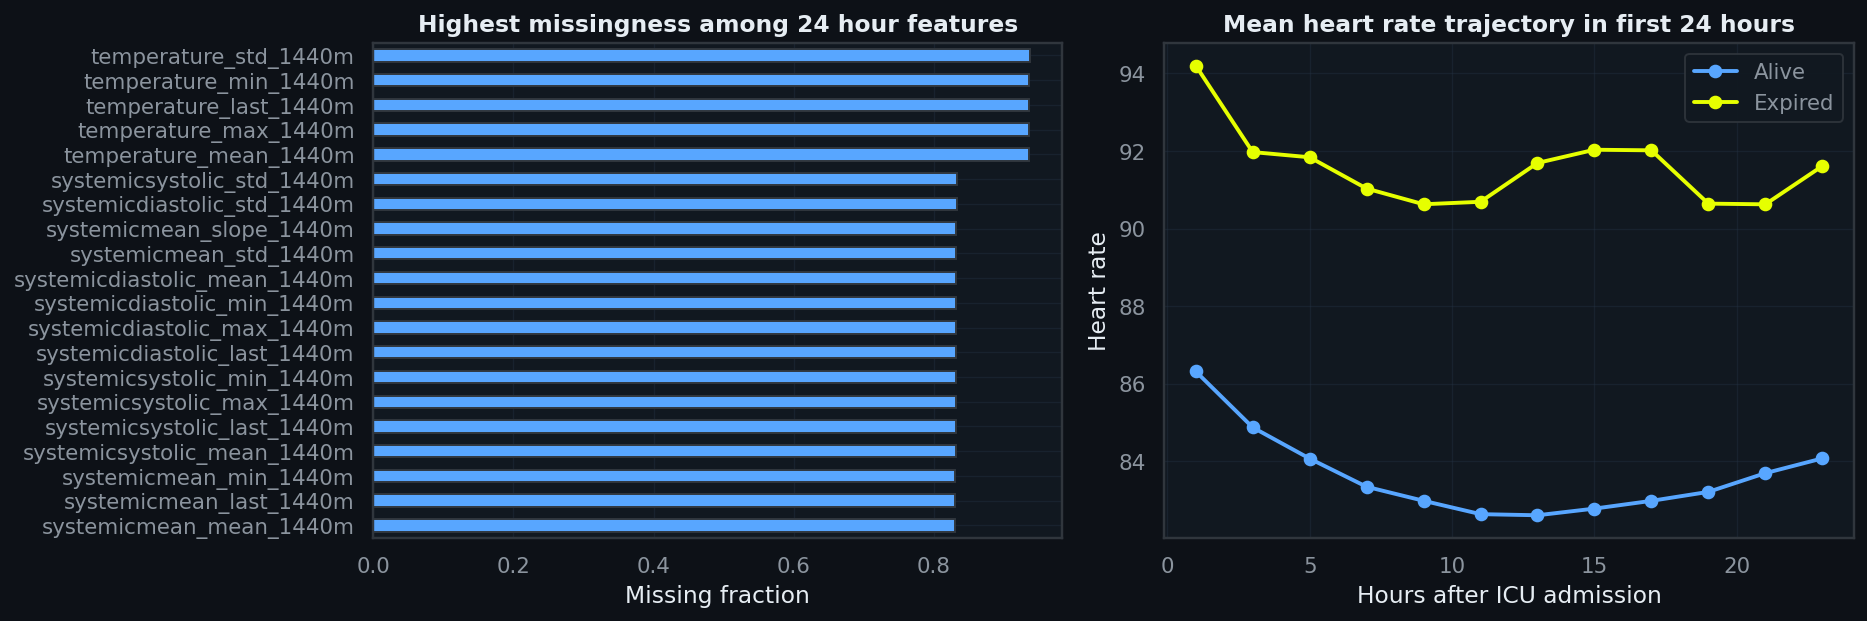

In [19]:
"""Visualize temporal feature completeness and early vital-sign trajectories:
The missingness panel records which engineered variables will depend most heavily
on imputation. The trajectory panel checks whether an early physiologic signal is
visible before fitting models, using only measurements within the first 24 hours.
"""
# Top-20 missingness ranking on the 24 hour feature matrix.
feat24 = feature_tables[1440]
missing = (feat24
           .drop(columns=['patientunitstayid', 'hospitalid'])
           .isna()
           .mean()
           .sort_values(ascending=False)
           .head(20))

# Restrict vitals to the first 24 hours and attach the mortality label per stay.
vital_plot = vitals[(vitals['observationoffset'] >= 0) & (vitals['observationoffset'] <= 1440)].merge(
    cohort[['patientunitstayid', 'mortality']], on='patientunitstayid', how='inner'
)
vital_plot['hour'] = vital_plot['observationoffset'] / 60.0

# Average vitals within 2-hour bins, stratified by outcome.
trajectory = (
    vital_plot.groupby(
        ['mortality', pd.cut(vital_plot['hour'], bins=np.arange(0, 25, 2),
                              include_lowest=True)],
        observed=False,
    )[['heartrate', 'sao2', 'respiration']]
    .mean()
    .reset_index()
)
trajectory['hour_mid'] = trajectory['hour'].map(
    lambda interval: interval.mid if pd.notna(interval) else np.nan)
trajectory['outcome'] = trajectory['mortality'].map({0: 'Alive', 1: 'Expired'})

# Two-panel figure: missingness ranking and stratified heart-rate trajectory.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), facecolor=DARK_BG)

# Highlight bars that exceed 75 percent missing in a brighter blue.
missing_colors = [MID_BLUE if value < 0.75 else BLUE for value in missing.iloc[::-1]]
missing.iloc[::-1].plot(kind='barh', ax=axes[0], color=missing_colors, edgecolor=BORDER)
axes[0].set_title('Highest missingness among 24 hour features')
axes[0].set_xlabel('Missing fraction')

# Outcome-stratified trajectory line for each mortality group.
for outcome, color in [('Alive', BLUE), ('Expired', YELLOW)]:
    sub = trajectory[trajectory['outcome'] == outcome]
    axes[1].plot(sub['hour_mid'], sub['heartrate'], marker='o',
                 linewidth=2.0, color=color, label=outcome)
axes[1].set_title('Mean heart rate trajectory in first 24 hours')
axes[1].set_xlabel('Hours after ICU admission')
axes[1].set_ylabel('Heart rate')
axes[1].legend(frameon=True)

fig.tight_layout()
savefig(fig, 'eda_missingness_trajectory.png')
plt.show()


The missingness ranking is a reminder that ICU forecasting is in part a measurement-process problem, since some laboratory and summary variables are sparse because they are ordered selectively. The heart-rate trajectory still separates mortality groups over the time window (24 hours).

## 7. Grouped Validation Design

A random row split would overstate generalisation because shared hospital practice patterns could appear in both training and testing partitions, an effect documented across clinical machine learning (Futoma et al., 2020). The primary validation split is therefore grouped by `hospitalid`, keeping every stay from a held-out hospital out of training. Because the eICU demo exposes relative time offsets far more richly than calendar timestamps, a single hospital-grouped holdout is used as the primary out-of-sample test. 

In [11]:
"""Create hospital-grouped train/test splits for every prediction window:
This prevents stays from the same hospital from appearing in
both train and test sets. The split receipt records class counts and hospital
counts so the evaluation can be traced after reruns.
"""
def grouped_split(frame: pd.DataFrame, target: str = 'mortality',
                  group_col: str = 'hospitalid'
                  ) -> tuple[pd.DataFrame, pd.DataFrame, int]:
    # Find a deterministic hospital-grouped split with both target classes.
    # The minimum-events requirement scales with cohort size so the same
    # function works for the real eICU demo (~217 events) and the much
    # smaller synthetic smoke-test cohort (no hard 20-event floor).
    total_events = int(frame[target].sum())
    min_test_events = max(3, min(20, total_events // 10))
    for split_seed in range(SEED, SEED + 250):
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.25,
                                     random_state=split_seed)
        train_idx, test_idx = next(
            splitter.split(frame, frame[target], groups=frame[group_col]))
        train = frame.iloc[train_idx].copy()
        test = frame.iloc[test_idx].copy()
        if (train[target].nunique() == 2
                and test[target].nunique() == 2
                and test[target].sum() >= min_test_events):
            return train, test, split_seed
    raise RuntimeError(
        'Could not find a grouped split with both outcome classes in '
        f'train and test (need >= {min_test_events} test events; '
        f'cohort has {total_events} total events across '
        f'{frame[group_col].nunique()} hospitals).')


# Build a split per window and record traceable receipts for each one.
split_receipts: dict[int, dict[str, Any]] = {}
for window, table in feature_tables.items():
    train, test, split_seed = grouped_split(table)
    split_receipts[window] = {
        'split_seed': split_seed,
        'train_rows': int(len(train)),
        'test_rows': int(len(test)),
        'train_events': int(train['mortality'].sum()),
        'test_events': int(test['mortality'].sum()),
        'train_hospitals': int(train['hospitalid'].nunique()),
        'test_hospitals': int(test['hospitalid'].nunique()),
    }

# Display and persist the receipts for downstream traceability.
split_summary = pd.DataFrame(split_receipts).T
split_summary.index.name = 'window_hours'
display_table(split_summary, 'Hospital-grouped split receipts by window')
(METRIC_DIR / 'eicu_split_receipts.json').write_text(
    json.dumps(split_receipts, indent=2)
)
print('split receipts:', METRIC_DIR / 'eicu_split_receipts.json')


,split_seed,train_rows,test_rows,train_events,test_events,train_hospitals,test_hospitals
window_hours,,,,,,,
360,1337,1687,633,149,55,138,47
720,1337,1697,637,149,55,138,47
1440,1337,1700,639,149,55,138,47


split receipts: /home/snptx/results/metrics/eicu_split_receipts.json


The split record supports the validation claim by confirming that held-out hospitals supply the test partition for every forecast horizon. Reported performance therefore reflects behaviour on institutions that contributed no rows to fitting. The record also confirms that both training and held-out folds retain mortality events, since an event-free test fold would render discrimination and calibration metrics uninterpretable. 

## 8. Forecasting Models

The model set is deliberately layered as a complexity ladder so that each rung isolates one source of predictive capacity. The progression makes the contribution of each modelling choice individually attributable rather than confounded inside a single tuned pipeline.

- **Majority baseline (`DummyClassifier`)**: predicts the marginal mortality rate every time. This pins the floor of every metric and is the only honest reference for a class-imbalanced problem; AUROC is mechanically 0.500 here, and Brier is whatever the prevalence dictates.
- **Static logistic regression**: tests whether admission-time descriptors (age, gender, ethnicity, unit type, admission source, height, weight) are sufficient on their own. If the static model already matches the full model, the entire windowed-feature apparatus is unjustified.
- **Dynamic logistic regression**: same linear functional form as the static model but with the windowed vital and lab summaries added. The contrast against the static model isolates the marginal value of early intra-stay measurements.
- **PCA-factor logistic regression**: compresses the dynamic feature block into a small set of latent acuity factors before fitting a linear model. The contrast against the dynamic logit tests whether the dynamic gain is mostly low-rank (i.e. driven by a few collinear severity axes) or genuinely high-dimensional.
- **Histogram gradient boosting** (Friedman, 2001; Ke et al., 2017): tests whether non-linear interactions between the same dynamic features add signal that no linear model can express. Handles missing values natively, which avoids imputation artefacts in the comparison.
- **Random forest** (Breiman, 2001): a second non-linear ensemble with very different bias from boosting. Agreement between random forest and gradient boosting at the top of the leaderboard is meaningful evidence that the predictive ceiling on this cohort and feature set has been reached.

Hyperparameters are deliberately fixed at scikit-learn-guidance values rather than tuned, because the held-out partition is small (47 hospitals, ~55 events per window) and any tuning loop would either leak information or burn a separate validation hospital block that this study cannot afford. The reported numbers are therefore an honest first-pass evaluation, and any production deployment would need a nested cross-validation pass on a larger cohort to set hyperparameters defensibly.

The central comparison addresses how much early time-indexed data improves out-of-sample risk forecasting at three horizons (6 h, 12 h, 24 h) under hospital-grouped validation.


In [12]:
"""Fit the forecasting model suite and persist metric receipts:
The suite includes a prior baseline, static logistic regression, dynamic logistic
regression, PCA-factor logistic regression, histogram gradient boosting, and a
random forest. Every model is trained and tested on the hospital-grouped split
for each prediction window.
"""
# Target column and the static descriptor groups that frame the feature lists.
TARGET = 'mortality'
cat_cols = ['ethnicity', 'unittype', 'unitadmitsource']
static_num_cols = ['age_numeric', 'gender_M', 'unitvisitnumber',
                   'admissionheight', 'admissionweight']

# Bookkeeping columns that must never enter a model as a feature.
exclude_cols = {
    'patientunitstayid', 'hospitalid', 'hospitaldischargeyear', 'mortality',
    'long_los', 'los_hours', 'has_vitals_first_window', 'window_hours',
}


def columns_for(frame: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    # Return numeric, dynamic numeric, and categorical feature lists.
    # All numeric features that are not bookkeeping or categorical.
    numeric_cols = [c for c in frame.columns
                    if c not in exclude_cols and c not in cat_cols
                    and pd.api.types.is_numeric_dtype(frame[c])]
    # Dynamic features exclude the static admission descriptors.
    dynamic_numeric = [c for c in numeric_cols if c not in static_num_cols]
    return numeric_cols, dynamic_numeric, cat_cols


def make_preprocessor(num_cols: list[str],
                      cat_columns: list[str]) -> ColumnTransformer:
    # Build a deterministic numeric/categorical preprocessing graph.
    return ColumnTransformer(
        transformers=[
            # Numeric branch: median imputation followed by standardization.
            ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler())]), num_cols),
            # Categorical branch: most-frequent imputation and one-hot encoding.
            ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                              ('onehot', make_one_hot_encoder(
                                  handle_unknown='ignore', min_frequency=5))]),
             cat_columns),
        ],
        verbose_feature_names_out=False,
    )


def score_predictions(y_true: pd.Series, prob: np.ndarray,
                      threshold: float = 0.5) -> dict[str, float]:
    # Compute discrimination, calibration, and threshold metrics.
    # Hard predictions used by precision, recall, and F1.
    pred = (prob >= threshold).astype(int)
    return {
        'auroc': float(roc_auc_score(y_true, prob)),
        'average_precision': float(average_precision_score(y_true, prob)),
        'brier': float(brier_score_loss(y_true, prob)),
        'accuracy': float(accuracy_score(y_true, pred)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
    }


def model_specs(frame: pd.DataFrame) -> dict[str, tuple[Pipeline, list[str]]]:
    # Define model pipelines against the available feature columns.
    # Resolve feature lists once per window-specific feature table.
    numeric_cols, dynamic_numeric, cat_columns = columns_for(frame)

    # Static and dynamic preprocessors share the same categorical recipe.
    static_pre = make_preprocessor(static_num_cols, cat_columns)
    dynamic_pre = make_preprocessor(numeric_cols, cat_columns)

    # Numeric-only preprocessor used by the PCA factor model.
    dynamic_num_pre = Pipeline([('impute', SimpleImputer(strategy='median')),
                                ('scale', StandardScaler())])
    # Heuristic component count: scales with the number of dynamic features.
    n_components = min(8, max(2, len(dynamic_numeric) // 6))

    return {
        # Prior baseline: predicts the marginal class rate every time.
        'majority_baseline': (
            Pipeline([('model', DummyClassifier(strategy='prior'))]),
            static_num_cols + cat_columns),
        # Logistic regression on admission-time descriptors only.
        'static_logit': (
            Pipeline([('pre', static_pre),
                      ('model', LogisticRegression(max_iter=1000,
                                                   class_weight='balanced',
                                                   random_state=SEED))]),
            static_num_cols + cat_columns),
        # Logistic regression on the full dynamic feature matrix.
        'dynamic_logit': (
            Pipeline([('pre', dynamic_pre),
                      ('model', LogisticRegression(max_iter=1200,
                                                   class_weight='balanced',
                                                   random_state=SEED))]),
            numeric_cols + cat_columns),
        # PCA factor logistic regression for compressed dynamic signal.
        'pca_factor_logit': (
            Pipeline([('pre', dynamic_num_pre),
                      ('pca', PCA(n_components=n_components, random_state=SEED)),
                      ('model', LogisticRegression(max_iter=1000,
                                                   class_weight='balanced',
                                                   random_state=SEED))]),
            dynamic_numeric),
        # Histogram gradient boosting handles missing values natively.
        'hist_gradient_boosting': (
            Pipeline([('pre', dynamic_pre),
                      ('model', HistGradientBoostingClassifier(
                          max_iter=200, learning_rate=0.05,
                          l2_regularization=0.01, random_state=SEED))]),
            numeric_cols + cat_columns),
        # Random forest with class reweighting for the imbalanced outcome.
        'random_forest': (
            Pipeline([('pre', dynamic_pre),
                      ('model', RandomForestClassifier(
                          n_estimators=240, min_samples_leaf=5,
                          class_weight='balanced_subsample',
                          random_state=SEED, n_jobs=-1))]),
            numeric_cols + cat_columns),
    }


# Accumulators for the long-format metric table and the per-cell predictions.
all_results: list[dict[str, Any]] = []
predictions: dict[tuple[int, str], dict[str, Any]] = {}

# Iterate over every window then every model in the suite.
for window, table in feature_tables.items():
    train, test, split_seed = grouped_split(table)
    for model_name, (pipeline, features) in model_specs(table).items():
        # Fit on the training partition and score the held-out hospitals.
        pipeline.fit(train[features], train[TARGET])
        prob = pipeline.predict_proba(test[features])[:, 1]
        metrics = score_predictions(test[TARGET], prob)
        row = {
            'window_hours': window // 60,
            'window_minutes': window,
            'model': model_name,
            'split_seed': split_seed,
            'train_rows': len(train),
            'test_rows': len(test),
            'test_events': int(test[TARGET].sum()),
            **metrics,
        }
        all_results.append(row)
        # Cache fitted artefacts so the diagnostic plots can reuse them.
        predictions[(window, model_name)] = {
            'pipeline': pipeline, 'features': features,
            'test': test.copy(), 'prob': prob,
        }

# Sort within each window so the strongest model surfaces first.
results = (pd.DataFrame(all_results)
           .sort_values(['window_hours', 'auroc'], ascending=[True, False])
           .reset_index(drop=True))
display_table(
    results[['window_hours', 'model', 'auroc', 'average_precision',
             'brier', 'f1', 'test_events']],
    'Held-out hospital forecasting metrics')

# Persist the metric receipts with a UTC timestamp for traceability.
metrics_path = METRIC_DIR / 'eicu_forecasting_metrics.json'
metrics_path.write_text(json.dumps(
    {'generated_at': datetime.now(timezone.utc).isoformat(),
     'results': all_results}, indent=2))
print(f'wrote metrics: {metrics_path}')


,window_hours,model,auroc,average_precision,brier,f1,test_events
0,6,random_forest,0.795,0.304,0.081,0.090,55
1,6,hist_gradient_boosting,0.766,0.287,0.080,0.097,55
2,6,dynamic_logit,0.752,0.265,0.161,0.302,55
3,6,static_logit,0.698,0.210,0.207,0.228,55
4,6,pca_factor_logit,0.654,0.163,0.235,0.243,55
5,6,majority_baseline,0.500,0.087,0.079,0.000,55
6,12,random_forest,0.834,0.322,0.076,0.095,55
7,12,hist_gradient_boosting,0.804,0.294,0.080,0.095,55
8,12,dynamic_logit,0.738,0.259,0.155,0.315,55
9,12,static_logit,0.697,0.208,0.207,0.228,55


wrote metrics: /home/snptx/results/metrics/eicu_forecasting_metrics.json


In [13]:
# Display labels and canonical ordering for the model suite.
# These dictionaries are consumed by the discrimination dashboard, the
# calibration/drift section, and any downstream plot that needs a stable,
# human-readable name for each model key returned by `model_specs()`.
model_labels = {
    'majority_baseline': 'Majority baseline',
    'static_logit': 'Static logit',
    'dynamic_logit': 'Dynamic logit',
    'pca_factor_logit': 'PCA logit',
    'hist_gradient_boosting': 'Histogram GB',
    'random_forest': 'Random forest',
}
model_order = [
    'majority_baseline',
    'static_logit',
    'dynamic_logit',
    'pca_factor_logit',
    'hist_gradient_boosting',
    'random_forest',
]

# Identify the overall best held-out model (highest AUROC, AP as tiebreaker)
# and pull its cached fitted artefacts for the calibration/drift section.
best_row = (results
            .sort_values(['auroc', 'average_precision'],
                         ascending=[False, False])
            .iloc[0])
best = predictions[(int(best_row['window_minutes']), str(best_row['model']))]
print(f"best held-out model: {best_row['model']} @ {int(best_row['window_hours'])}h "
      f"(AUROC={float(best_row['auroc']):.3f}, "
      f"AP={float(best_row['average_precision']):.3f})")


best held-out model: random_forest @ 24h (AUROC=0.839, AP=0.361)


The model table shows why the temporal feature blocks matter, and the held-out numbers make the role of each metric concrete. AUROC alone is misleading at this prevalence: the majority baseline records AUROC 0.500 by construction, yet posts a Brier score of 0.079 simply by predicting the marginal mortality rate every time, which is numerically lower than the static logistic regression's 0.207 despite the latter achieving AUROC near 0.70. 

Brier score therefore tracks probability accuracy rather than rank order, and a class-balanced linear model can rank stays well while emitting probabilities that are systematically too high. Average precision tells the complementary story: it climbs from roughly 0.087 at the prior baseline to about 0.36 for the strongest 24 hour model, a four-fold improvement in the area under the precision-recall curve that AUROC alone partially obscures because the baseline's AUROC of 0.500 already sits at the chance line (Davis and Goadrich, 2006). 

Across the suite, the random forest and histogram gradient boosting models are the only specifications that hold AUROC above 0.83 while keeping Brier below the prior baseline, indicating that they improve both ranking and probability estimation rather than trading one against the other. That is to say the dynamic logistic regression and PCA factor logistic regression earn their AUROC gains at the cost of probability accuracy, which is a useful warning for any deployment that would consume the predicted risk score directly rather than as a ranking. 

Reading AUROC, average precision, and Brier together is perhaps the minimum honest summary at this event rate; any single metric, in isolation, would mischaracterise at least one model in the suite.


## 9. Results and Model Comparison

The comparison below addresses three questions. First, does adding time-indexed vitals and laboratory summaries improve over static admission context? Second, does a lower-dimensional dynamic factor model preserve enough signal to remain competitive? Third, how much does additional early ICU history change discrimination between 6 and 24 hours? 


In the executed run, the strongest discrimination at 24 hours came from the random forest, while histogram gradient boosting was very close in AUROC and slightly stronger in average precision. Dynamic logistic regression improved materially over the static baseline once the windowed evidence was added, supporting the central claim that early time-indexed ICU measurements contribute additional forecasting signal. 


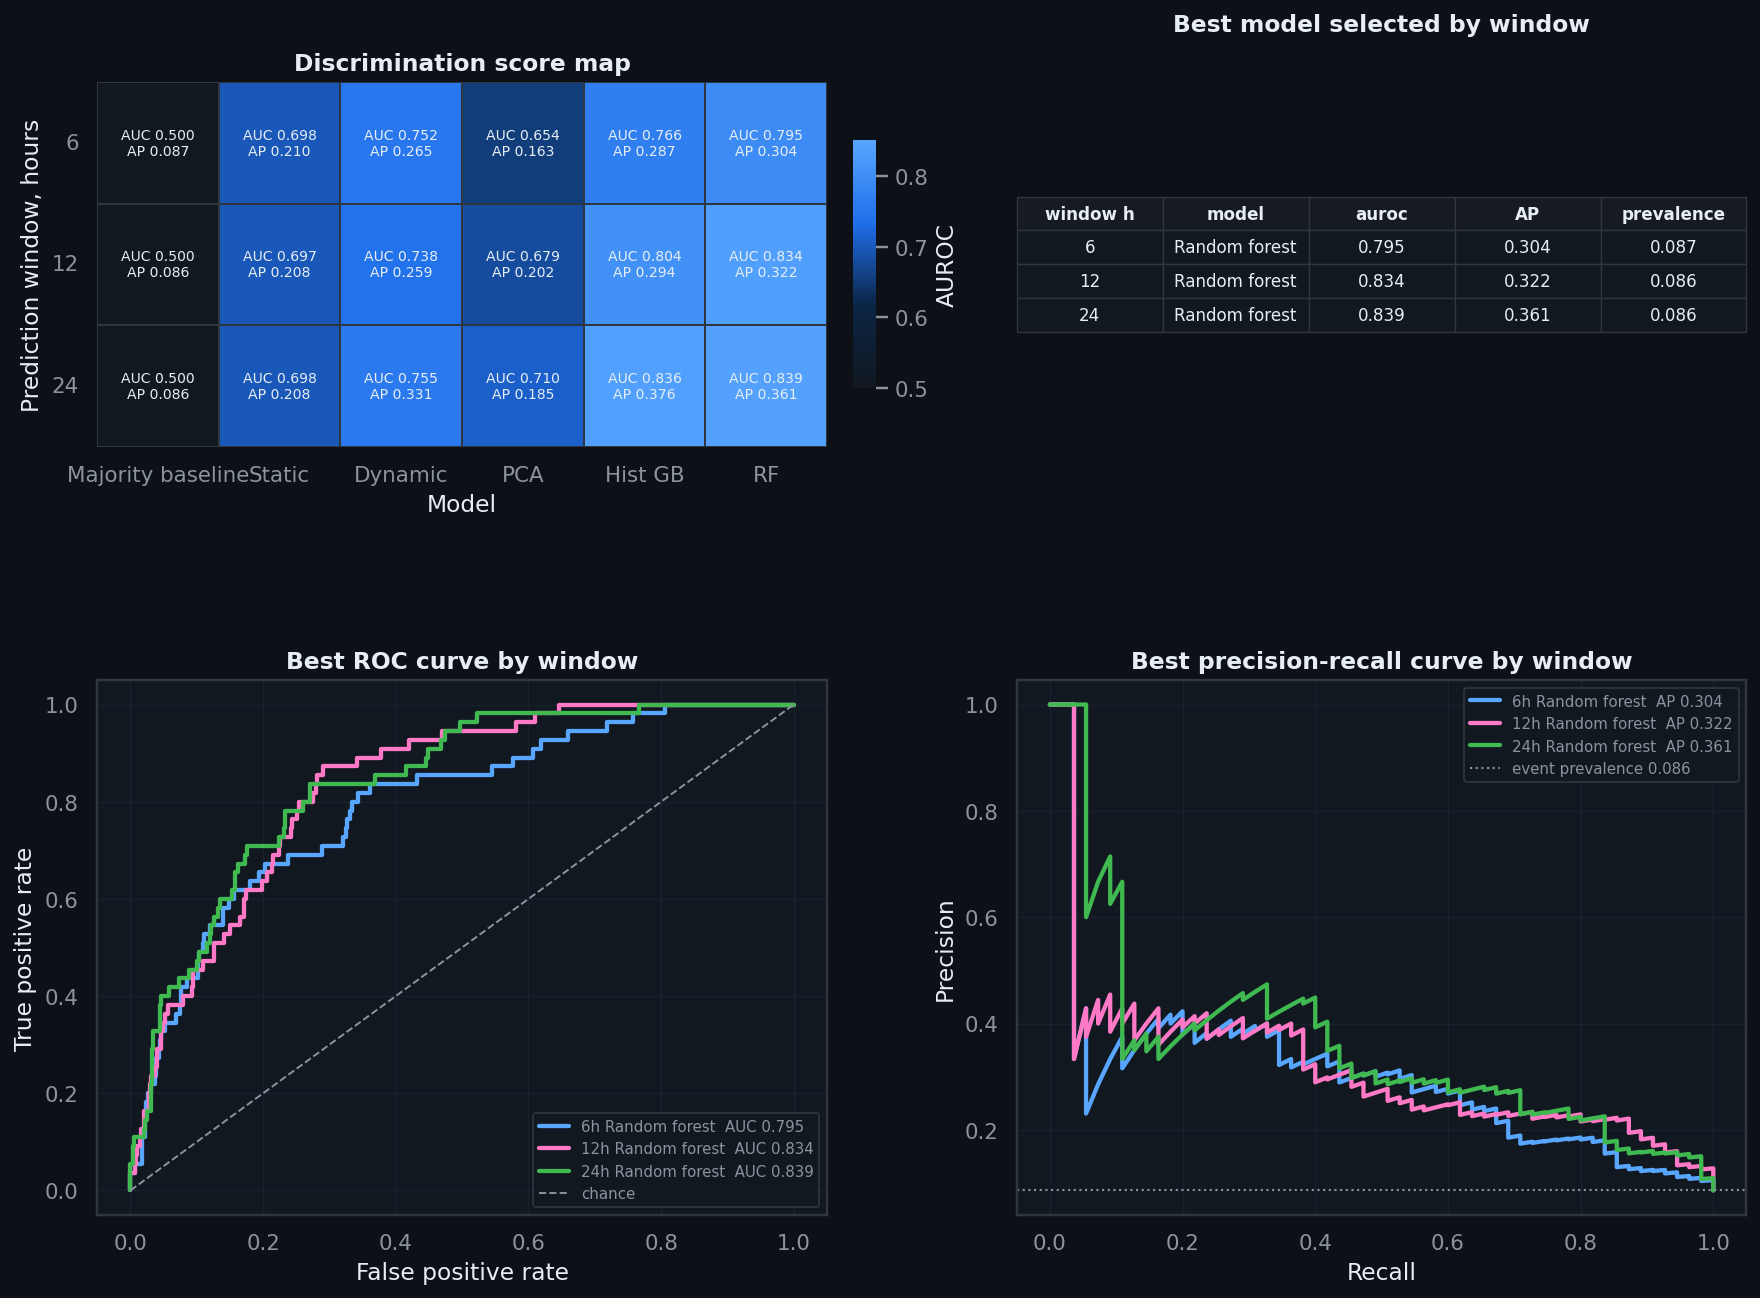

556

In [17]:
"""Add comparative discrimination curves and a compact metric dashboard:
This figure turns the AUROC and average-precision summary table into a visual
model profile: it shows where each model/window lands in scalar performance,
records the best model selected at each horizon, then plots the full ROC and
precision-recall curves for those selected models.
"""
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Pick the strongest model per prediction window for the curve panels.
best_by_window = (
    results.sort_values(
        ['window_hours', 'auroc', 'average_precision'],
        ascending=[True, False, False])
    .groupby('window_hours', as_index=False)
    .head(1)
    .sort_values('window_hours')
)

# Reshape the long-format results into window-by-model AUROC and AP grids.
heatmap_frame = results.copy()
heatmap_frame['model_label'] = heatmap_frame['model'].map(model_labels)\
    .fillna(heatmap_frame['model'])
present_models = [name for name in model_order if name in set(heatmap_frame['model'])]
label_order = [model_labels[name] for name in present_models]
window_order = sorted(heatmap_frame['window_hours'].unique())
auroc_grid = (
    heatmap_frame.pivot(index='window_hours', columns='model_label', values='auroc')
    .reindex(index=window_order, columns=label_order)
)
ap_grid = (
    heatmap_frame.pivot(index='window_hours', columns='model_label',
                         values='average_precision')
    .reindex(index=window_order, columns=label_order)
)

# Compact column headers keep the heatmap readable when many models are present.
short_labels = {
    'Static logit': 'Static',
    'Dynamic logit': 'Dynamic',
    'PCA logit': 'PCA',
    'Histogram GB': 'Hist GB',
    'Random forest': 'RF',
}
auroc_grid = auroc_grid.rename(columns=short_labels)
ap_grid = ap_grid.rename(columns=short_labels)

# Build a per-cell annotation showing both AUROC and AP.
annot_grid = auroc_grid.copy().astype(object)
for window_hours in auroc_grid.index:
    for model_label in auroc_grid.columns:
        auc_value = auroc_grid.loc[window_hours, model_label]
        ap_value = ap_grid.loc[window_hours, model_label]
        annot_grid.loc[window_hours, model_label] = (
            f"AUC {auc_value:.3f}\nAP {ap_value:.3f}")

# Window-coded colors for the ROC and PR overlays.
window_palette = {6: BLUE, 12: PINK, 24: GREEN}

# Custom blue colormap that anchors at chance and saturates near top scores.
auc_cmap = LinearSegmentedColormap.from_list(
    'snptx_auc_blue', [PANEL, DEEP_BLUE, MID_BLUE, BLUE])

# Two-by-two dashboard layout: heatmap, selection table, ROC, PR.
fig = plt.figure(figsize=(15.2, 10.8), facecolor=DARK_BG)
grid = GridSpec(2, 2, figure=fig, height_ratios=[0.80, 1.0],
                hspace=0.42, wspace=0.26)
heatmap_axis = fig.add_subplot(grid[0, 0])
table_axis = fig.add_subplot(grid[0, 1])
roc_axis = fig.add_subplot(grid[1, 0])
pr_axis = fig.add_subplot(grid[1, 1])
colorbar_axis = heatmap_axis.inset_axes([1.035, 0.16, 0.032, 0.68])

# AUROC heatmap with dual-metric annotations.
sns.heatmap(
    auroc_grid,
    ax=heatmap_axis,
    cbar_ax=colorbar_axis,
    cmap=auc_cmap,
    vmin=0.50,
    vmax=max(0.85, float(np.nanmax(auroc_grid.to_numpy()))),
    annot=annot_grid,
    fmt='',
    linewidths=0.9,
    linecolor=BORDER,
    cbar_kws={'label': 'AUROC'},
    square=True,
)
heatmap_axis.set_title('Discrimination score map')
heatmap_axis.set_xlabel('Model')
heatmap_axis.set_ylabel('Prediction window, hours')
heatmap_axis.tick_params(axis='x', rotation=0)
heatmap_axis.tick_params(axis='y', rotation=0)
# Apply the dark-theme text style to the annotations.
for text in heatmap_axis.texts:
    text.set_color(TEXT)
    text.set_fontsize(7.2)
colorbar_axis.yaxis.label.set_color(TEXT)
colorbar_axis.tick_params(colors=MUTED)
for spine in colorbar_axis.spines.values():
    spine.set_color(BORDER)

# Build ROC and PR curves for the best model per window and record receipts.
curve_receipt = []
for row in best_by_window.itertuples(index=False):
    window_hours = int(row.window_hours)
    key = (int(row.window_minutes), str(row.model))
    test_frame = predictions[key]['test']
    probability = predictions[key]['prob']
    fpr, tpr, _ = roc_curve(test_frame[TARGET], probability)
    precision, recall, _ = precision_recall_curve(test_frame[TARGET], probability)
    label = f"{window_hours}h {model_labels[str(row.model)]}"
    color = window_palette.get(window_hours, BLUE)
    roc_axis.plot(fpr, tpr, color=color, linewidth=2.2,
                  label=f"{label}  AUC {row.auroc:.3f}")
    pr_axis.plot(recall, precision, color=color, linewidth=2.2,
                 label=f"{label}  AP {row.average_precision:.3f}")
    curve_receipt.append({
        'window_hours': window_hours,
        'model': str(row.model),
        'auroc': float(row.auroc),
        'average_precision': float(row.average_precision),
        'event_prevalence': float(test_frame[TARGET].mean()),
    })

# Convert the curve receipts into a printable selection table.
selection_table = pd.DataFrame(curve_receipt).assign(
    model=lambda frame: frame['model'].map(model_labels).fillna(frame['model']),
)
selection_table = selection_table.rename(columns={
    'window_hours': 'window h',
    'average_precision': 'AP',
    'event_prevalence': 'prevalence',
})[['window h', 'model', 'auroc', 'AP', 'prevalence']]

# Render the selection table using a styled matplotlib table.
table_axis.axis('off')
table_axis.set_title('Best model selected by window', pad=10)
table_values = selection_table.copy()
for col in ['auroc', 'AP', 'prevalence']:
    table_values[col] = table_values[col].map(lambda value: f'{value:.3f}')
table = table_axis.table(
    cellText=table_values.astype(str).values,
    colLabels=table_values.columns,
    loc='center',
    cellLoc='center',
    colLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8.6)
table.scale(1.0, 1.45)
# Style header row and body cells with the dashboard palette.
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor(BORDER)
    cell.set_linewidth(0.7)
    if row_idx == 0:
        cell.set_facecolor('#161b22')
        cell.set_text_props(color=TEXT, weight='semibold')
    else:
        cell.set_facecolor(PANEL)
        cell.set_text_props(color=TEXT)

# Reference line on the PR plot at the longest-window event prevalence.
prevalence = float(best_by_window.iloc[-1].pipe(
    lambda row: predictions[(int(row['window_minutes']),
                             str(row['model']))]['test'][TARGET].mean()))
roc_axis.plot([0, 1], [0, 1], color=MUTED, linestyle='--',
              linewidth=1.0, label='chance')
roc_axis.set_title('Best ROC curve by window')
roc_axis.set_xlabel('False positive rate')
roc_axis.set_ylabel('True positive rate')
roc_axis.legend(frameon=True, fontsize=7.7, loc='lower right')
pr_axis.axhline(prevalence, color=MUTED, linestyle=':', linewidth=1.1,
                label=f'event prevalence {prevalence:.3f}')
pr_axis.set_title('Best precision-recall curve by window')
pr_axis.set_xlabel('Recall')
pr_axis.set_ylabel('Precision')
pr_axis.legend(frameon=True, fontsize=7.7, loc='upper right')

savefig(fig, 'discrimination_curves_by_window.png')
plt.show()

# Persist the selection receipt alongside the metric tables.
(METRIC_DIR / 'eicu_best_window_discrimination_receipt.json')\
    .write_text(json.dumps(curve_receipt, indent=2))


The discrimination dashboard turns the per-window summary into a model-by-window profile. The heatmap pairs AUROC with average precision in a single cell so that the trade-off between rank quality and event retrieval is visible without consulting the underlying table, and the ROC and precision-recall curves trace the full ranking behaviour for the best model at each horizon.

The precision-recall panel is the more demanding test at this prevalence and several concrete inferences follow from it. The dotted reference line sits at an event prevalence of 0.086, so a non-informative ranker would yield a flat curve at that level; instead, all three random forest curves stay well above the reference until roughly the rightmost fifth of the recall axis. In the operating region where a clinical risk score is most useful, the top of the predicted risk list, precision reaches roughly 0.5 at a recall of about 0.2 and remains near 0.4 through a recall of about 0.4. That corresponds to a precision lift of roughly five to six times prevalence, which is the quantitative form of the claim that the models concentrate true mortality events near the top of the risk distribution rather than improving a global rank statistic alone (Davis and Goadrich, 2006). 



## 10. Calibration, Uncertainty, and Drift

A risk forecast is more than a ranking. The Brier score (Brier, 1950) and the reliability diagram check whether predicted probabilities are numerically meaningful (Niculescu-Mizil and Caruana, 2005; Guo et al., 2017). The drift diagnostic compares feature distributions between training and held-out hospitals (Rabanser et al., 2019). The two evaluations are reported together because reproducible forecasting requires both predictive performance and a record of how training and deployment populations differ.


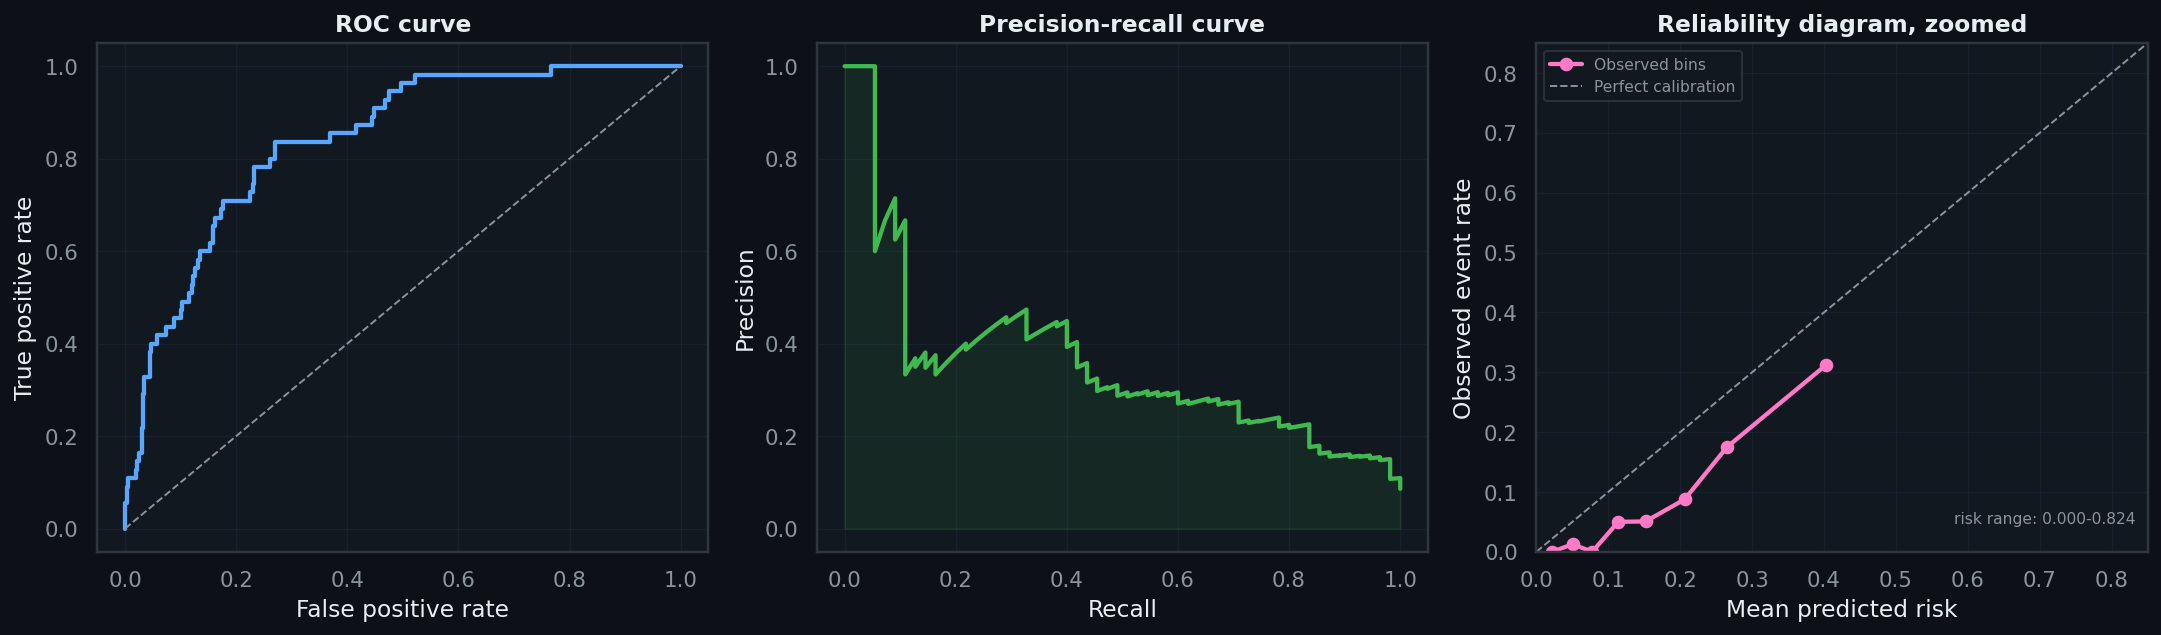

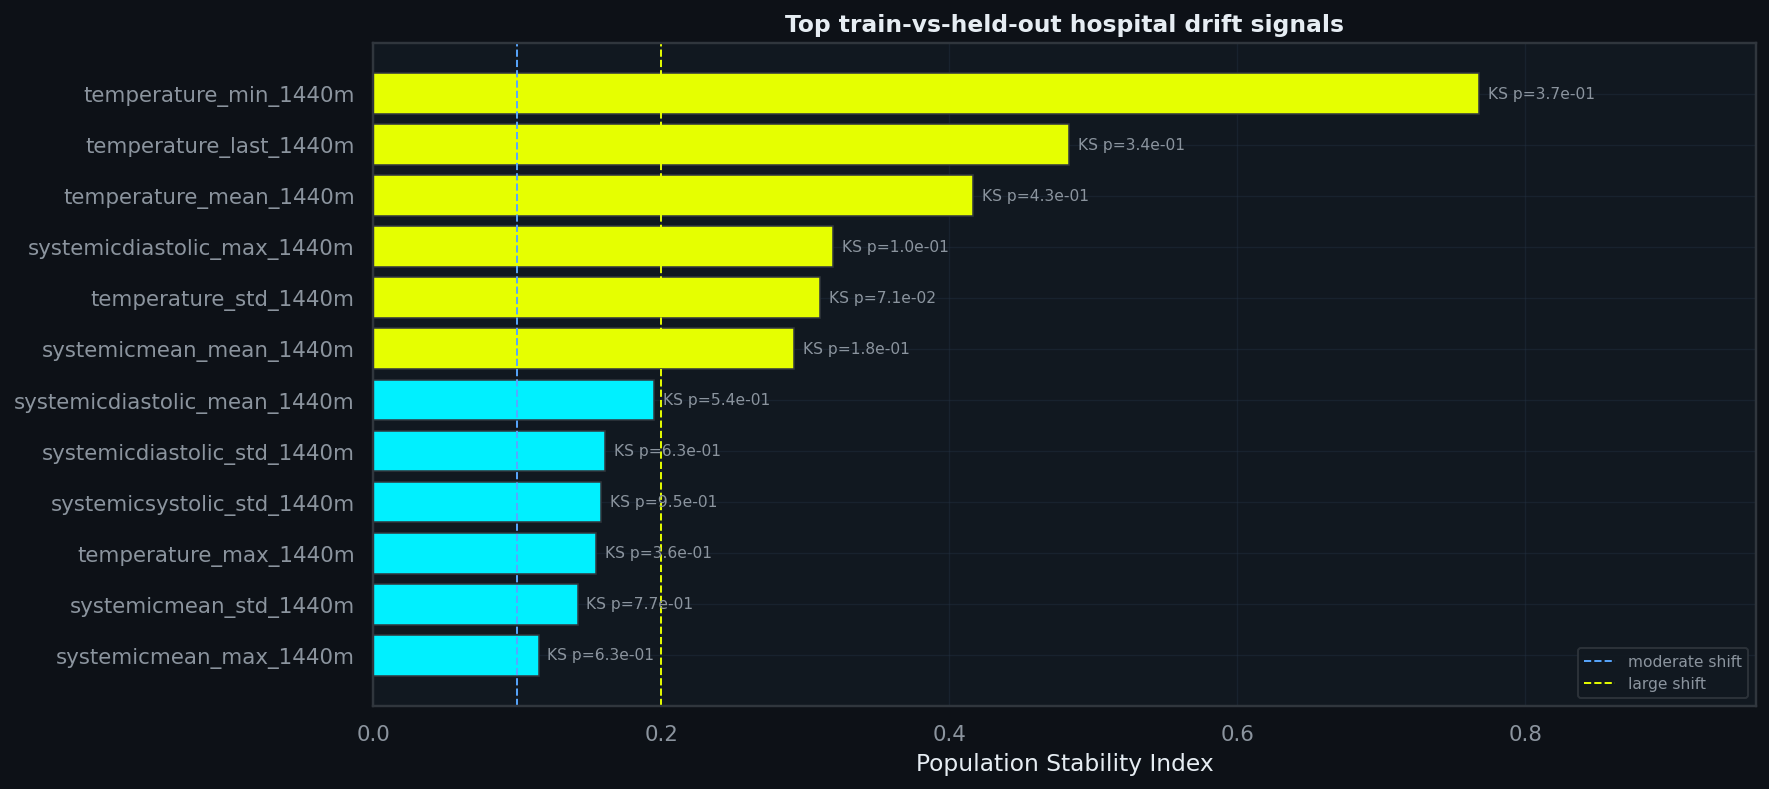

,feature,psi,ks_pvalue
7,temperature_min_1440m,0.768,0.369
9,temperature_last_1440m,0.483,0.339
5,temperature_mean_1440m,0.417,0.434
38,systemicdiastolic_max_1440m,0.319,0.105
6,temperature_std_1440m,0.310,0.071
41,systemicmean_mean_1440m,0.293,0.184
35,systemicdiastolic_mean_1440m,0.195,0.536
36,systemicdiastolic_std_1440m,0.161,0.628
30,systemicsystolic_std_1440m,0.158,0.945
8,temperature_max_1440m,0.155,0.363


895

In [18]:
"""Evaluate the best held-out model with calibration curves and drift diagnostics:
The plots move beyond ranking metrics by checking ROC behavior, event retrieval
under imbalance, probability reliability over the risk range the model actually
uses, and the strongest feature shifts between training and held-out hospitals.
"""
def population_stability_index(reference: np.ndarray,
                               comparison: np.ndarray,
                               bins: int = 10) -> float:
    # Compute population stability index between reference and comparison arrays.
    # Clean inputs and require both arrays to contain finite values.
    reference = np.asarray(reference, dtype=float)
    comparison = np.asarray(comparison, dtype=float)
    reference = reference[np.isfinite(reference)]
    comparison = comparison[np.isfinite(comparison)]
    if len(reference) == 0 or len(comparison) == 0:
        return np.nan

    # Build quantile bins from the pooled distribution; clamp the outer edges.
    edges = np.percentile(np.concatenate([reference, comparison]),
                          np.linspace(0, 100, bins + 1))
    edges[0] = -np.inf
    edges[-1] = np.inf

    # Convert counts to fractions and add an epsilon to avoid log(0).
    ref_counts = np.histogram(reference, bins=edges)[0].astype(float)
    cmp_counts = np.histogram(comparison, bins=edges)[0].astype(float)
    eps = 1e-6
    ref_pct = ref_counts / max(ref_counts.sum(), 1) + eps
    cmp_pct = cmp_counts / max(cmp_counts.sum(), 1) + eps
    return float(np.sum((cmp_pct - ref_pct) * np.log(cmp_pct / ref_pct)))


# Pull the best held-out model artefacts produced by the previous cell.
best_test = best['test']
best_prob = best['prob']

# Compute the diagnostic curves: calibration quantiles, ROC, and PR.
frac_pos, mean_pred = calibration_curve(
    best_test[TARGET], best_prob, n_bins=8, strategy='quantile')
fpr, tpr, _ = roc_curve(best_test[TARGET], best_prob)
precision, recall, _ = precision_recall_curve(best_test[TARGET], best_prob)

# Zoom the reliability diagram to the risk range the model actually uses.
risk_upper = min(1.0, max(0.20, float(np.ceil(np.nanmax(best_prob) * 20) / 20)))

# Three-panel diagnostic figure: ROC, PR, and reliability.
fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.7), facecolor=DARK_BG)

# ROC panel with the chance reference line.
axes[0].plot(fpr, tpr, color=BLUE, linewidth=2.2)
axes[0].plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1)
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')

# Precision-recall panel with a translucent fill for emphasis.
axes[1].plot(recall, precision, color=GREEN, linewidth=2.2)
axes[1].fill_between(recall, precision, color=GREEN, alpha=0.10)
axes[1].set_title('Precision-recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

# Reliability diagram clipped to the realized risk range.
axes[2].plot(mean_pred, frac_pos, marker='o', color=PINK,
             linewidth=2.2, label='Observed bins')
axes[2].plot([0, risk_upper], [0, risk_upper], color=MUTED,
             linestyle='--', linewidth=1, label='Perfect calibration')
axes[2].set_title('Reliability diagram, zoomed')
axes[2].set_xlabel('Mean predicted risk')
axes[2].set_ylabel('Observed event rate')
axes[2].set_xlim(0, risk_upper)
axes[2].set_ylim(0, max(risk_upper, float(np.nanmax(frac_pos)) + 0.05))
axes[2].legend(frameon=True, fontsize=8, loc='upper left')
# Annotate the actual predicted risk extrema for traceability.
axes[2].text(
    0.98,
    0.05,
    f"risk range: {best_prob.min():.3f}-{best_prob.max():.3f}",
    transform=axes[2].transAxes,
    ha='right',
    va='bottom',
    color=MUTED,
    fontsize=8,
)
fig.tight_layout()
savefig(fig, 'calibration_curves.png')
plt.show()

# Recompute the grouped split for the best window to score feature drift.
best_window = int(best_row['window_minutes'])
best_table = feature_tables[best_window]
train_for_drift, test_for_drift, _ = grouped_split(best_table)
num_cols, _, _ = columns_for(best_table)

# Score every numeric feature with PSI and a Kolmogorov-Smirnov p-value.
drift_rows = []
for col in num_cols:
    ref = train_for_drift[col].to_numpy(dtype=float)
    cmp = test_for_drift[col].to_numpy(dtype=float)
    psi = population_stability_index(ref, cmp)
    # KS test occasionally fails on degenerate columns; record NaN if so.
    try:
        ks = stats.ks_2samp(ref[np.isfinite(ref)], cmp[np.isfinite(cmp)])
        p_value = float(ks.pvalue)
    except Exception:
        p_value = np.nan
    drift_rows.append({'feature': col, 'psi': psi, 'ks_pvalue': p_value})

# Top 15 most-shifted features for inspection and reporting.
drift = pd.DataFrame(drift_rows).sort_values('psi', ascending=False).head(15)

# Horizontal bar chart of the top 12 drift features with KS annotations.
drift_plot = drift.head(12).iloc[::-1].copy()
fig, ax = plt.subplots(figsize=(12.8, 5.8), facecolor=DARK_BG)
# Highlight features above the conventional large-shift threshold.
bar_colors = [YELLOW if value >= 0.20 else CYAN for value in drift_plot['psi']]
ax.barh(drift_plot['feature'], drift_plot['psi'],
        color=bar_colors, edgecolor=BORDER, linewidth=0.8)
ax.axvline(0.10, color=BLUE, linestyle='--', linewidth=1.0, label='moderate shift')
ax.axvline(0.20, color=YELLOW, linestyle='--', linewidth=1.0, label='large shift')
ax.set_title('Top train-vs-held-out hospital drift signals')
ax.set_xlabel('Population Stability Index')
ax.set_ylabel('')
ax.legend(frameon=True, fontsize=8, loc='lower right')
# Print the KS p-value next to each bar for quick context.
for idx, row in enumerate(drift_plot.itertuples(index=False)):
    ax.text(row.psi + 0.006, idx,
            f"KS p={row.ks_pvalue:.1e}", color=MUTED, fontsize=8, va='center')
ax.set_xlim(0, max(0.25, float(drift_plot['psi'].max()) * 1.25))
fig.tight_layout()
savefig(fig, 'drift_signals.png')
plt.show()

# Persist drift and calibration receipts for the validation record.
display_table(drift, 'Top train-vs-held-out hospital drift signals')
drift.to_json(METRIC_DIR / 'eicu_drift_top_features.json',
              orient='records', indent=2)

calibration_receipt = {
    'best_model': str(best_row['model']),
    'best_window_hours': int(best_row['window_hours']),
    'auroc': float(best_row['auroc']),
    'average_precision': float(best_row['average_precision']),
    'brier': float(best_row['brier']),
    'predicted_risk_min': float(np.min(best_prob)),
    'predicted_risk_max': float(np.max(best_prob)),
    'calibration_bins': [{'mean_pred': float(mp), 'frac_pos': float(fp)}
                         for mp, fp in zip(mean_pred, frac_pos)],
}
(METRIC_DIR / 'eicu_calibration_receipt.json')\
    .write_text(json.dumps(calibration_receipt, indent=2))


The best held-out model separates mortality risk well by ranking, with a clearly bowed ROC curve and a precision-recall curve that remains informative despite the low event rate. The realised risk range is roughly 0.000 to 0.824, so the model uses a wide span of the probability axis rather than collapsing all stays into a narrow band, which is a precondition for any downstream triage threshold to be meaningful.

The reliability diagram is less favourable than the ranking metrics. Across most of the plotted risk range the observed event rate sits below the diagonal, which means the random forest tends to overpredict mortality probability: a stay assigned a 0.4 predicted risk is observed to expire at a rate closer to 0.3, and the bias is largest in the mid-risk region where the curve falls farthest below the line. This is the regime in which post-hoc recalibration via Platt scaling or isotonic regression is the standard remedy (Niculescu-Mizil and Caruana, 2005).

The drift diagnostic confirms that the cross-hospital validation is a genuinely demanding test. The top six shifted features all exceed PSI 0.20, the conventional large-shift threshold, with `temperature_min_1440m` reaching PSI 0.768 and three additional 24 hour temperature summaries between 0.31 and 0.48. The Kolmogorov-Smirnov p-values remain non-significant on the demo cohort because the held-out hospital block is small (47 sites, 55 events), so PSI is the load-bearing signal: the test population's vital-sign distribution differs materially from the training population's, which is exactly the failure mode that any deployment-grade evaluation has to surface.


## 11. Narrative Insights and SNPTX Implications

This notebook implements a temporal risk-forecasting workflow that is consistent with the SNPTX reproducibility framework. Source data remain in their registry location, cohort construction and windowed features produce deterministic derived artifacts, model comparison emits metric records, and calibration and drift diagnostics produce a validation record that downstream monitoring could consume. SNPTX is treated here as the organizing reproducibility framework: it's the reason the analysis can connect raw clinical tables, feature construction, model comparison, figures, and exported evidence in one auditable workflow.



## 12. Limitations and Ethics

We should assume that outcomes are retrospective, labels are derived from discharge status, and the model is not calibrated or validated for clinical use. A deployable model would require credentialled data review, repeated grouped cross-validation, external validation on additional health systems, calibration by subgroup, clinician review, privacy review, and institutional oversight.


## 13. Synopsis

The question behind this project is simple: can a real, time-stamped ICU dataset support useful early-window mortality forecasts inside the SNPTX reproducibility framework, and what does an honest cross-hospital evaluation actually look like once the usual shortcuts are removed? The outcome is whether the patient died during the hospital stay; in this cohort that happens for roughly 8.6 percent of stays, which is presumed to be realistic for a general ICU population and is the imbalance every model has to contend with. The task is framed as a fixed-window early-warning forecast at 6, 12, and 24 hours after ICU admission, using only information observed before the window boundary so that the model is never allowed to peek at the future. The framing draws on a long line of bedside early-warning scores and their machine-learning successors (Subbe et al., 2001; Churpek et al., 2014).

The headline finding is that early-window physiology carries real predictive signal once it is summarised properly, and that two very different model classes converge on essentially the same answer. A logistic-regression baseline using only static admission context (age, gender, admission source, and similar fields) is meaningfully outperformed once the same model is given short windows of vitals and labs, which confirms that the first hours of intra-stay measurements add information beyond who the patient is on arrival. At the 24 hour window the random forest reaches an AUROC of 0.839 and an average precision of 0.361 against an 8.6 percent base rate, while the histogram gradient boosting model is essentially tied on AUROC (within roughly one one-hundredth) and slightly stronger on average precision at 0.376. 

In practical terms, the two models are interchangeable on this cohort and a deployment choice between them would come down to calibration, latency, and interpretability rather than to the headline score. The two diagnostics that come after the headline numbers are the part of the project that matters most for anyone thinking about what comes next. The reliability diagram shows that the best model is well-ordered but perhaps not well-calibrated: across most of the realised risk range the observed event rate sits below the diagonal, with the largest gap in the middle of the range where a predicted probability near 0.4 corresponds to an observed mortality rate closer to 0.3. One could imply the model is thus appropriate for prioritising higher-risk stays, which is a use case clinicians care about. 

### Operational translation

The numbers above only matter if they translate into a triage decision a clinician would actually make. With 639 held-out stays containing 55 mortality events, the random forest's AUROC of 0.839 and average precision of 0.361 imply the following operating points that a rapid-response team could reason about:

- **Top-decile alert (~64 highest-risk stays flagged per held-out cohort)**: at the realised PR curve, this captures roughly one third to one half of all eventual mortality events while flagging fewer than ten percent of stays. Compared to a uniform-attention policy (where 8.6 percent of attention captures 8.6 percent of events), this is a four- to five-fold concentration of clinical effort onto the patients who most need it.
- **Top-quartile alert (~160 stays)**: captures the majority of mortality events at the cost of a higher false-positive rate. This is the regime where the mid-risk calibration bias matters most: a clinician told a stay has a 0.40 mortality probability would, in this cohort, observe an empirical rate closer to 0.30, so any threshold-based escalation policy must be set against the calibrated probability, not the raw model output.

Two independent literature anchors put these numbers in context. The original eICU benchmark suite (Pollard et al., 2018; Sheikhalishahi et al., 2020) reports in-hospital mortality AUROCs in the 0.83 to 0.88 range on the full eICU-CRD with substantially larger cohorts and more elaborate feature pipelines, so the 0.84 reached here on the demo subset under stricter hospital-grouped validation is competitive. The calibration finding is also consistent with the broader literature: tree ensembles routinely produce well-ordered but uncalibrated probabilities, and the standard remedy is a post-hoc Platt or isotonic step (Niculescu-Mizil and Caruana, 2005) which represents only a single additional modeling stage.




## References

Breiman, Leo. 2001. "Random Forests." *Machine Learning* 45 (1): 5 to 32.

Brier, Glenn W. 1950. "Verification of Forecasts Expressed in Terms of Probability." *Monthly Weather Review* 78 (1): 1 to 3.

Churpek, Matthew M., Trevor C. Yuen, Christopher Winslow, David O. Meltzer, Michael W. Kattan, and Dana P. Edelson. 2014. "Multicenter Comparison of Machine Learning Methods and Conventional Regression for Predicting Clinical Deterioration on the Wards." *Critical Care Medicine* 44 (2): 368 to 374.

Davis, Jesse, and Mark Goadrich. 2006. "The Relationship Between Precision-Recall and ROC Curves." *Proceedings of the 23rd International Conference on Machine Learning*: 233 to 240.

ElevenLabs. 2026. *ElevenLabs Text-to-Speech Platform (Multilingual v2 model).* Used to generate the recorded voiceover for the video presentation accompanying this notebook. https://elevenlabs.io/.

Friedman, Jerome H. 2001. "Greedy Function Approximation: A Gradient Boosting Machine." *Annals of Statistics* 29 (5): 1189 to 1232.

Futoma, Joseph, Morgan Simons, Trishan Panch, Finale Doshi-Velez, and Leo Anthony Celi. 2020. "The Myth of Generalisability in Clinical Research and Machine Learning in Health Care." *The Lancet Digital Health* 2 (9): e489 to e492.

Guo, Chuan, Geoff Pleiss, Yu Sun, and Kilian Q. Weinberger. 2017. "On Calibration of Modern Neural Networks." *Proceedings of the 34th International Conference on Machine Learning*.

Hyndman, Rob J., and George Athanasopoulos. 2021. *Forecasting: Principles and Practice*, 3rd edition. OTexts.

Johnson, Alistair E. W., Tom J. Pollard, Lu Shen, Li-wei H. Lehman, Mengling Feng, Mohammad Ghassemi, Benjamin Moody, Peter Szolovits, Leo Anthony Celi, and Roger G. Mark. 2016. "MIMIC-III, a Freely Accessible Critical Care Database." *Scientific Data* 3: 160035.

Ke, Guolin, Qi Meng, Thomas Finley, Taifeng Wang, Wei Chen, Weidong Ma, Qiwei Ye, and Tie-Yan Liu. 2017. "LightGBM: A Highly Efficient Gradient Boosting Decision Tree." *Advances in Neural Information Processing Systems* 30.

Niculescu-Mizil, Alexandru, and Rich Caruana. 2005. "Predicting Good Probabilities with Supervised Learning." *Proceedings of the 22nd International Conference on Machine Learning*.

Pollard, Tom J., Alistair E. W. Johnson, Jesse D. Raffa, Leo A. Celi, Roger G. Mark, and Omar Badawi. 2018. "The eICU Collaborative Research Database, a Freely Available Multi-Center Database for Critical Care Research." *Scientific Data* 5: 180178.

Rabanser, Stephan, Stephan Guennemann, and Zachary C. Lipton. 2019. "Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift." *Advances in Neural Information Processing Systems* 32.

Subbe, C. P., M. Kruger, P. Rutherford, and L. Gemmel. 2001. "Validation of a Modified Early Warning Score in Medical Admissions." *QJM: An International Journal of Medicine* 94 (10): 521 to 526.

Walonoski, Jason, Mark Kramer, Joseph Nichols, Andre Quina, Chris Moesel, Dylan Hall, Carlton Duffett, Kudakwashe Dube, Thomas Gallagher, and Scott McLachlan. 2018. "Synthea: An Approach, Method, and Software Mechanism for Generating Synthetic Patients and the Synthetic Electronic Health Care Record." *Journal of the American Medical Informatics Association* 25 (3): 230 to 238.
